## Part A - Predicting Market Capitalization with Multiple Linear Regression

In [ ]:
import os
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pl
%matplotlib inline
pl.rcParams["figure.figsize"] = [6.000, 6.145] 
from scipy.stats import ttest_ind
import statistics
from sklearn.linear_model import LinearRegression
import sys 

if not sys.warnoptions:
    import warnings
    #suppress warning messages (those with peach background)
    warnings.simplefilter('ignore')
    warnings.filterwarnings('ignore')

### Data Preparation

1) Read in data\
2) Subset variables of interest for analysis\
3) Clean variable names\
4) Remove rows with missing y variable or rows with all missing x variables\
5) Build model equation\
6) Create categorical variables\
7) Convert any categorical variable into dummies and remove any original categorical variables turned into dummies\
8) Replace erroneous data with NaN\
9) Prorate x variables where necessary to adjust for length of fiscal year\
10) Re-build model equation if necessary\
11) Treat missing data for x variables
12) Re-build model equation if necessary\
13) Remove highly correlated variables\
14) Duplicate clean dataset\
15) Train Test Split (80%-20%)

#### 1) Read in data

In [ ]:
df = pd.read_csv('Financial_Info_SG_Firms.csv')
df.head(5)

,Worldscope Permanent ID,DS_CODE,Year,Actual Loan Losses,Accumulated Depreciation,Accounts Payable,Accrued Payroll,Accrued Taxes,Accounting Method For Long Term Investment >50%,Accounting Standards Followed,...,Unconsolidated/Parent Company Pretax Earnings Per Share,U.S. GAAP Information Available,Weighted Cost Of Debt,Unrealized Valuation Gains/Losses Total,Unfunded Pension Liabilities,Unrealized Valuation Gains/Losses Investments,Unrealized Valuation Gains/Losses Investment Property,Unrealized Valuation Gains/Losses Biological Assets,Unrealized Valuation Gains/Losses Hedges/Derivatives,Unrealized Valuation Gains/Losses Other
0,C702B7140,13039P,1973,"$$ER: 4540,NO DATA VALUES FOUND",NaN,NaN,"$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND",NaN,NaN,...,"$$ER: 4540,NO DATA VALUES FOUND","$$ER: E100,INVALID CODE OR EXPRESSION ENTERED","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND","$$ER: 4540,NO DATA VALUES FOUND"
1,C702B7140,13039P,1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C702B7140,13039P,1975,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C702B7140,13039P,1976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C702B7140,13039P,1977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Replace $$ER: 4540,NO DATA VALUES FOUND & missing values with with np.nan
df.replace('$$ER: 4540,NO DATA VALUES FOUND', np.nan, inplace=True)
df.replace('', np.nan, inplace=True)

# check data
df.head(2)

,Worldscope Permanent ID,DS_CODE,Year,Actual Loan Losses,Accumulated Depreciation,Accounts Payable,Accrued Payroll,Accrued Taxes,Accounting Method For Long Term Investment >50%,Accounting Standards Followed,...,Unconsolidated/Parent Company Pretax Earnings Per Share,U.S. GAAP Information Available,Weighted Cost Of Debt,Unrealized Valuation Gains/Losses Total,Unfunded Pension Liabilities,Unrealized Valuation Gains/Losses Investments,Unrealized Valuation Gains/Losses Investment Property,Unrealized Valuation Gains/Losses Biological Assets,Unrealized Valuation Gains/Losses Hedges/Derivatives,Unrealized Valuation Gains/Losses Other
0,C702B7140,13039P,1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,"$$ER: E100,INVALID CODE OR EXPRESSION ENTERED",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C702B7140,13039P,1974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 2) Subset variables of interest for analysis

In [ ]:
var_analysis = ['Year', 'Worldscope Permanent ID','DS_CODE','Accounts Receivables Days','Accounts Receivables Days 5 Year Average', 
                'Auditors Opinion','Cash & Short Term Investments','Cash', 'Cash Dividends Paid Total','Cash Flow/Sales', 
                'Dividend Yield 5 Year Average High','Dividend Yield 5 Year Average Low','EBIT/Total Interest Expense Ratio', 
                'Equity 1 Year Annual Growth','Funds From Operations','Interest Expense On Debt','Income Taxes', 
                'Gross Profit Margin','Gross Profit Margin 5 Year Average','Long Term Borrowings','Length Of Fiscal Year', 
                'Long Term Liabilities Per Share','Long Term Debt % Common Equity','Net Sales Or Revenues', 'Operating Expenses Total', 
                'Net Income After Preferred Dividends (Basic EPS)', 'Market Capitalization Fiscal Period End', 
                'Net Income 3 Year Annual Growth', 'Net Debt', 'Preferred Stock % Total Capital', 'Pretax Margin', 
                'Price/Earnings Ratio 5 Year Average Average High-Low', 'Price/Sales Per Share Ratio', 'Return On Equity Total %', 
                'Return On Assets', 'Return On Assets 5 Year Average', 'Return On Equity Per Share', 'Total Debt', 
                'Total Debt % Total Capital', 'Total Liabilities']

df = df.loc[:, var_analysis]

In [ ]:
df.drop(['Year', 'Worldscope Permanent ID','DS_CODE'], axis=1, inplace=True)
print('\nThe dataset has',df.shape[0],'rows &',df.shape[1],'columns.')


The dataset has 53277 rows & 37 columns.


#### 3) Clean Variable Names

In [ ]:
#clean up variable names:

cn = list(df) # store variables name

for var in cn:   
    vnew = ''.join([ c if c.isalnum() else '_' for c in var ]) # loop through every element of each xvar to check if presence of non-alphanumeric character and if yes, replace with '_'
    if vnew[0].isdigit(): # If variable name begins with a digit, insert '_' as prefix  
        vnew = '_' + vnew
    df.rename(columns={var: vnew}, inplace=True) # replace the original variable name in dataframe with the cleaned headers.
    
cn = list(df) #store the cleaned column names
print('Variables in Dataframe:', cn, '\n')
cs = set(df) # store the unique cleaned column names
rx = len(cn) - len(cs) # take the difference in len of cn and cs to ensure no duplicated columns
print('\nThere are ', rx, 'duplicated columns in the dataframe.') # no duplicated columns

Variables in Dataframe: ['Accounts_Receivables_Days', 'Accounts_Receivables_Days_5_Year_Average', 'Auditors_Opinion', 'Cash___Short_Term_Investments', 'Cash', 'Cash_Dividends_Paid_Total', 'Cash_Flow_Sales', 'Dividend_Yield_5_Year_Average_High', 'Dividend_Yield_5_Year_Average_Low', 'EBIT_Total_Interest_Expense_Ratio', 'Equity_1_Year_Annual_Growth', 'Funds_From_Operations', 'Interest_Expense_On_Debt', 'Income_Taxes', 'Gross_Profit_Margin', 'Gross_Profit_Margin_5_Year_Average', 'Long_Term_Borrowings', 'Length_Of_Fiscal_Year', 'Long_Term_Liabilities_Per_Share', 'Long_Term_Debt___Common_Equity', 'Net_Sales_Or_Revenues', 'Operating_Expenses_Total', 'Net_Income_After_Preferred_Dividends__Basic_EPS_', 'Market_Capitalization_Fiscal_Period_End', 'Net_Income_3_Year_Annual_Growth', 'Net_Debt', 'Preferred_Stock___Total_Capital', 'Pretax_Margin', 'Price_Earnings_Ratio_5_Year_Average_Average_High_Low', 'Price_Sales_Per_Share_Ratio', 'Return_On_Equity_Total__', 'Return_On_Assets', 'Return_On_Assets_5_

#### 4) Remove rows where Y missing or is non-number, or X values all missing

In [ ]:
yvar = 'Market_Capitalization_Fiscal_Period_End' # assign y-variable

df = df[df[yvar].notnull()].dropna(how='all', subset=[x for x in list(df) if x != yvar]) # reomve rows where y is missing first, thereafter remove remaining rows with all x values missing

#remove rows where Y is not a number:
df = df[df[yvar].apply(lambda x: type(x) in [int, np.int64, float, np.float64])].dropna(axis=1, how='all') 

nrow = df.shape[0] 
ncol = df.shape[1] 
print('\nThe dataset has',nrow,'rows &',ncol,'columns, after deleting rows with missing or non-number Y ('+ yvar +'), or missing all X values.')


The dataset has 14727 rows & 37 columns, after deleting rows with missing or non-number Y (Market_Capitalization_Fiscal_Period_End), or missing all X values.


In [ ]:
#number of distinct or unique values in Y:
uq = len(set(df[yvar].dropna()))     
ymed = np.median(df[yvar]) # compute the median value market cap
if int(ymed) == ymed: # check if integer of ymed is ymed itself, if true, we store ymed as integer of ymed instead of a float
    ymed = int(ymed)
print('\nNumber of unique values in Y variable ('+ yvar +', with median', str(ymed) + ') =', uq) # apply str() to convert ymed to string\ as Python is unable to add an integer to a word.


Number of unique values in Y variable (Market_Capitalization_Fiscal_Period_End, with median 163552) = 13899


#### 5) Build model equation

In [ ]:
modeleq = yvar + ' ~' 
prt1 = True
catlist = [] # create a list to store categorical variables
df2 = df[yvar] # create a series with yvar
cn = list(df)

for xvar in cn:
    if xvar == 'Auditors_Opinion':   
        df[xvar] = df[xvar].astype('category')
        catlist.append(xvar) 
    #print(catlist)
    if xvar != yvar:
        if modeleq[-1] == '~':
            modeleq = modeleq + ' ' + xvar # if yes, replace modeleq = yvar ~ with modeleq = yvar ~ xvar
        else:
            modeleq = modeleq + ' + ' + xvar 
        df2=pd.concat([df2,df[xvar]],axis=1) # concatenate xvar and yvar by axis columns (axis=1)

cn2 = list(df2)

print('\n'+ modeleq) # print the modeleq
print('\n', list(df2)) # print variables
print('\n', catlist)


Market_Capitalization_Fiscal_Period_End ~ Accounts_Receivables_Days + Accounts_Receivables_Days_5_Year_Average + Auditors_Opinion + Cash___Short_Term_Investments + Cash + Cash_Dividends_Paid_Total + Cash_Flow_Sales + Dividend_Yield_5_Year_Average_High + Dividend_Yield_5_Year_Average_Low + EBIT_Total_Interest_Expense_Ratio + Equity_1_Year_Annual_Growth + Funds_From_Operations + Interest_Expense_On_Debt + Income_Taxes + Gross_Profit_Margin + Gross_Profit_Margin_5_Year_Average + Long_Term_Borrowings + Length_Of_Fiscal_Year + Long_Term_Liabilities_Per_Share + Long_Term_Debt___Common_Equity + Net_Sales_Or_Revenues + Operating_Expenses_Total + Net_Income_After_Preferred_Dividends__Basic_EPS_ + Net_Income_3_Year_Annual_Growth + Net_Debt + Preferred_Stock___Total_Capital + Pretax_Margin + Price_Earnings_Ratio_5_Year_Average_Average_High_Low + Price_Sales_Per_Share_Ratio + Return_On_Equity_Total__ + Return_On_Assets + Return_On_Assets_5_Year_Average + Return_On_Equity_Per_Share + Total_Debt + 

#### 6) Create Categorical variables

In [ ]:
cols = [col for col in df2.columns if col not in ['Auditors_Opinion']]

if len(catlist) > 0:
    print('Creating dummy variables...')
    df2 = pd.concat([df2[cols],pd.get_dummies(df2['Auditors_Opinion'], drop_first=True)],axis=1)  # baseline is not_audited
                     
print(list(df2))

Creating dummy variables...
['Market_Capitalization_Fiscal_Period_End', 'Accounts_Receivables_Days', 'Accounts_Receivables_Days_5_Year_Average', 'Cash___Short_Term_Investments', 'Cash', 'Cash_Dividends_Paid_Total', 'Cash_Flow_Sales', 'Dividend_Yield_5_Year_Average_High', 'Dividend_Yield_5_Year_Average_Low', 'EBIT_Total_Interest_Expense_Ratio', 'Equity_1_Year_Annual_Growth', 'Funds_From_Operations', 'Interest_Expense_On_Debt', 'Income_Taxes', 'Gross_Profit_Margin', 'Gross_Profit_Margin_5_Year_Average', 'Long_Term_Borrowings', 'Length_Of_Fiscal_Year', 'Long_Term_Liabilities_Per_Share', 'Long_Term_Debt___Common_Equity', 'Net_Sales_Or_Revenues', 'Operating_Expenses_Total', 'Net_Income_After_Preferred_Dividends__Basic_EPS_', 'Net_Income_3_Year_Annual_Growth', 'Net_Debt', 'Preferred_Stock___Total_Capital', 'Pretax_Margin', 'Price_Earnings_Ratio_5_Year_Average_Average_High_Low', 'Price_Sales_Per_Share_Ratio', 'Return_On_Equity_Total__', 'Return_On_Assets', 'Return_On_Assets_5_Year_Average', '

#### 7) Remove duplicate columns and categorical variable turned into dummies

In [ ]:
if cn2!=list(df2):
    #remove any duplicate columns:
    replist=list(x for n, x in enumerate(cn2) if x in cn2[:n])
    if len(replist)>0:
        onename=replist[0]
        print(onename,'is a repeated column.')
        posn = list(df2).index(onename)
        colrange=[i for i in range(posn)]+[i for i in range(posn+1,len(list(df2)))] # exclude the dummy variable
        df2 = df2.iloc[:, colrange] #all rows, just colrange columns

cn2 = list(df2)

In [ ]:
# update dataframe dimension
if ncol != df2.shape[1]:
    ncol = df2.shape[1]
    if not prt1:
        print('')
print('The dataset for analysis has',nrow,'rows &',ncol,'columns, after any conversion of categorical variables to dummy variables.')

The dataset for analysis has 14727 rows & 38 columns, after any conversion of categorical variables to dummy variables.


#### 8) Replace erroneous data with null

In [ ]:
# Tabulate count of missing values in each var
missing_count = []

for var in cn2:
    m_count = df2[var].isnull().sum()
    missing_count.append(m_count)
    print(str(var) + ' has '+str(m_count), 'missing values.')

Market_Capitalization_Fiscal_Period_End has 0 missing values.
Accounts_Receivables_Days has 2392 missing values.
Accounts_Receivables_Days_5_Year_Average has 6929 missing values.
Cash___Short_Term_Investments has 472 missing values.
Cash has 2123 missing values.
Cash_Dividends_Paid_Total has 135 missing values.
Cash_Flow_Sales has 204 missing values.
Dividend_Yield_5_Year_Average_High has 5331 missing values.
Dividend_Yield_5_Year_Average_Low has 5324 missing values.
EBIT_Total_Interest_Expense_Ratio has 1711 missing values.
Equity_1_Year_Annual_Growth has 1021 missing values.
Funds_From_Operations has 25 missing values.
Interest_Expense_On_Debt has 313 missing values.
Income_Taxes has 92 missing values.
Gross_Profit_Margin has 1127 missing values.
Gross_Profit_Margin_5_Year_Average has 4811 missing values.
Long_Term_Borrowings has 2201 missing values.
Length_Of_Fiscal_Year has 570 missing values.
Long_Term_Liabilities_Per_Share has 1793 missing values.
Long_Term_Debt___Common_Equity h

In [ ]:
df2 = df2.apply(pd.to_numeric)

In [ ]:
# create list of variables where there are no restriction in the data value.  
var_norestrict = ['Qualified', 'Unqualified', 'Cash_Flow_Sales', 'EBIT_Total_Interest_Expense_Ratio', 'Equity_1_Year_Annual_Growth',
                  'Funds_From_Operations', 'Income_Taxes', 'Gross_Profit_Margin', 'Gross_Profit_Margin_5_Year_Average',
                  'Net_Income_After_Preferred_Dividends__Basic_EPS_', 'Net_Income_3_Year_Annual_Growth', 'Net_Debt', 
                  'Pretax_Margin', 'Price_Earnings_Ratio_5_Year_Average_Average_High_Low', 'Return_On_Equity_Total__', 
                  'Return_On_Assets', 'Return_On_Assets_5_Year_Average', 'Return_On_Equity_Per_Share']

# function to replace erronous data with np.nan
def reperr(x):
    if x<0:
        return np.nan
    else:
        return x

for var in cn2:
    if var not in var_norestrict:
        df2[var] = df2[var].apply(reperr)
    else:
        df2[var] = df2[var]

# tabulate new missing count after replacing error data with nan
missing_count_new = []
for var in cn2:
    m_count = df2[var].isnull().sum()
    missing_count_new.append(m_count)

# Summarise variables with Erronous data
err_val = pd.DataFrame({'Variables': cn2, 'Count_Missing': missing_count,
                            'Count_missing_new':missing_count_new})
err_val['Porportion of Missing Data_%'] = round(err_val['Count_missing_new']*100/14212, 2)
print('\n Summary of Variables with Missing Data:')
print(err_val)

err_val['count_error_data'] = err_val['Count_missing_new'] - err_val['Count_Missing']

print('\n Summary of Variables with Erronous Data:')
print(err_val[err_val.count_error_data>0][['Variables', 'count_error_data']])


 Summary of Variables with Missing Data:
                                            Variables  Count_Missing  \
0             Market_Capitalization_Fiscal_Period_End              0   
1                           Accounts_Receivables_Days           2392   
2            Accounts_Receivables_Days_5_Year_Average           6929   
3                       Cash___Short_Term_Investments            472   
4                                                Cash           2123   
5                           Cash_Dividends_Paid_Total            135   
6                                     Cash_Flow_Sales            204   
7                  Dividend_Yield_5_Year_Average_High           5331   
8                   Dividend_Yield_5_Year_Average_Low           5324   
9                   EBIT_Total_Interest_Expense_Ratio           1711   
10                        Equity_1_Year_Annual_Growth           1021   
11                              Funds_From_Operations             25   
12                    

#### 9) Pro-rate x Variables where necessary to adjust for length of fiscal year

In [ ]:
# create list of variables which require pro-rating as fiscal year > 365
prorate_var = ['Cash_Dividends_Paid_Total','Funds_From_Operations','Interest_Expense_On_Debt', 'Income_Taxes',
               'Net_Sales_Or_Revenues','Operating_Expenses_Total','Net_Income_After_Preferred_Dividends__Basic_EPS_']

# Create Pro-ration factor
df2['Prorate_Factor'] = (1/df2['Length_Of_Fiscal_Year'])*365

for var in prorate_var:
    df2[var] = df2[var]*df2['Prorate_Factor']
            
del df2['Length_Of_Fiscal_Year'] # drop variable as no longer needed
del df2['Prorate_Factor']
cn2 = list(df2)

In [ ]:
# obtain summary stats to ensure error data has been corrected
df2.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].style.format({'count':'{:,.0f}','mean':'{:.3n}',
                                                                                            'std':'{:.3n}','min':'{:.3n}','25%':'{:.3n}',
                                                                                            '50%':'{:.3n}','75%':'{:.3n}','max':'{:.3n}'})

,count,mean,std,min,25%,50%,75%,max
Market_Capitalization_Fiscal_Period_End,"14,727",3.95e+07,6.49e+08,0,4.68e+04,1.64e+05,7.56e+05,3.24e+10
Accounts_Receivables_Days,"12,335",357,1.33e+04,0,49,81,125,1.38e+06
Accounts_Receivables_Days_5_Year_Average,"7,798",183,1.42e+03,1,51,84,126,8.35e+04
Cash___Short_Term_Investments,"14,255",1.22e+07,2.37e+08,0,9.49e+03,3.12e+04,1.3e+05,1.23e+10
Cash,"12,604",4.06e+06,6.94e+07,0,4.13e+03,1.49e+04,5.87e+04,2.94e+09
Cash_Dividends_Paid_Total,"14,040",5.8e+05,1.14e+07,0,0,2.42e+03,1.68e+04,6.84e+08
Cash_Flow_Sales,"14,523",-14.4,2.97e+03,-1.43e+05,2.85,9.13,19.1,3.05e+05
Dividend_Yield_5_Year_Average_High,"9,396",2.21,20.5,0,0.31,1.39,2.8,1.95e+03
Dividend_Yield_5_Year_Average_Low,"9,403",4.21,35.5,0,0.77,2.81,5.17,3.31e+03
EBIT_Total_Interest_Expense_Ratio,"13,016",160,8.68e+03,-8.18e+05,1.26,5.25,18.3,3.43e+05


#### 10) Re-build Model

In [ ]:
if cn2!=list(df2):    
    cn2=list(df2)
    #print('gone thru redo of modeleq')
    modeleq = yvar + ' ~'
    for xvar in cn2:
        if xvar != yvar:
            if modeleq[-1] == '~':
                modeleq = modeleq + ' ' + xvar
            else:
                modeleq = modeleq + ' + ' + xvar

modx = modeleq.count('+') + 1
nrow = df2.shape[0]
print('\nModel has',nrow,'rows &',modx,'X variables.')
if modx < 51:
    print(modeleq)


Model has 14727 rows & 36 X variables.
Market_Capitalization_Fiscal_Period_End ~ Accounts_Receivables_Days + Accounts_Receivables_Days_5_Year_Average + Auditors_Opinion + Cash___Short_Term_Investments + Cash + Cash_Dividends_Paid_Total + Cash_Flow_Sales + Dividend_Yield_5_Year_Average_High + Dividend_Yield_5_Year_Average_Low + EBIT_Total_Interest_Expense_Ratio + Equity_1_Year_Annual_Growth + Funds_From_Operations + Interest_Expense_On_Debt + Income_Taxes + Gross_Profit_Margin + Gross_Profit_Margin_5_Year_Average + Long_Term_Borrowings + Length_Of_Fiscal_Year + Long_Term_Liabilities_Per_Share + Long_Term_Debt___Common_Equity + Net_Sales_Or_Revenues + Operating_Expenses_Total + Net_Income_After_Preferred_Dividends__Basic_EPS_ + Net_Income_3_Year_Annual_Growth + Net_Debt + Preferred_Stock___Total_Capital + Pretax_Margin + Price_Earnings_Ratio_5_Year_Average_Average_High_Low + Price_Sales_Per_Share_Ratio + Return_On_Equity_Total__ + Return_On_Assets + Return_On_Assets_5_Year_Average + Ret

#### 11) Clean data: Missing values for x variables

In [ ]:
#replace missing values (Nan, None) by column average:

for xvar in list(df2):
    if (xvar !=yvar):
        var = xvar
        newv = var + "_miss"
        b = df2[var].isnull().sum()
        #print('\nTotal "missing"', var, 'cases = ' + str(b) + '(' + str(round(b/(df2.shape[0])*100, 2)) + '%)')
        if b>0:
            s1 = pd.Series(0,range(df2.shape[0])) #series of 0
            s1.index = df2.index
            df2.insert(list(df2).index(var)+1, newv, s1) #insert dummy-for-missing into dataset
            df2[var][df2[var].isnull()] = np.nan #turns any None to Nan
            df2[newv][df2[var] != df2[var]] = 1 #mark NaN (and so None) as missing
            #replace NaN (& None)  with col mean
            m = pd.to_numeric(df2[var], errors='coerce').dropna().mean() #mean of finite numbers
            df2[var].fillna(m, inplace=True) #for Nan (and so None)

cn = list(df2)
df2 = df2.apply(pd.to_numeric)
df2['Qualified'] = df2['Qualified'].astype('category')        
df2['Unqualified'] = df2['Unqualified'].astype('category') 

In [ ]:
print('\nFill missing xvariables cells with average; insert dummy for missing (first 5 rows):')
df2.head(5)
#df2.dtypes


Fill missing xvariables cells with average; insert dummy for missing (first 5 rows):


,Market_Capitalization_Fiscal_Period_End,Accounts_Receivables_Days,Accounts_Receivables_Days_miss,Accounts_Receivables_Days_5_Year_Average,Accounts_Receivables_Days_5_Year_Average_miss,Cash___Short_Term_Investments,Cash___Short_Term_Investments_miss,Cash,Cash_miss,Cash_Dividends_Paid_Total,...,Return_On_Equity_Per_Share,Return_On_Equity_Per_Share_miss,Total_Debt,Total_Debt_miss,Total_Debt___Total_Capital,Total_Debt___Total_Capital_miss,Total_Liabilities,Total_Liabilities_miss,Qualified,Unqualified
27,59708.0,357.338549,1,183.201462,1,17333.0,0,14962.0,0,579513.468872,...,1.373116,1,18738.0,0,25.81,0,42538.0,0,0,1
28,59708.0,155.000000,0,183.201462,1,10196.0,0,7681.0,0,3000.000000,...,-7.700000,0,11797.0,0,19.10,0,20871.0,0,0,1
29,39805.0,126.000000,0,183.201462,1,4890.0,0,4091.0,0,0.000000,...,0.020000,0,14000.0,0,21.81,0,29288.0,0,0,1
30,121729.0,111.000000,0,183.201462,1,11807.0,0,8800.0,0,0.000000,...,0.260000,0,20581.0,0,24.00,0,50542.0,0,0,1
31,86232.0,84.000000,0,183.201462,1,11010.0,0,11005.0,0,1991.543716,...,17.940000,0,14116.0,0,15.78,0,50556.0,0,0,1


In [ ]:
# Check if missing data are missing at random / not missing at random.
# To do this, we run a t-test to compare the mean of market capitalisation at end of fiscal year between the missing group vs. the non missing group 
# if missing dummy is found to be significant, it means the data is not missing at random. Imputing using mean values will not be viable

# create a list to store the missing dummies created
dummies_missing = []

for xvar in cn:
    if xvar[-4:] == 'miss':
        df2[xvar] = df2[xvar].astype('category')
        dummies_missing.append(xvar)

# Use scipy.stats.ttest_ind.
mar_var = []
mnar_var = []
for var in dummies_missing:
    non_missing = df2[df2[var]==0][yvar]
    missing = df2[df2[var]==1][yvar]
    t, p = ttest_ind(missing, non_missing, equal_var=False)
    print("ttest_ind for ", var,": t = %g  p = %g" % (t, p))
    if p>0.05:
        mar_var.append(var[:-4])
    else:
        mnar_var.append(var[:-4])

print('\nVariables with Values Missing at Random are:')
print(mar_var)
print('\nNumber of Variables with Values Missing at Random are:', len(mar_var))
print('\nVariables with Values Not Missing at Random are:')
print(mnar_var)

ttest_ind for  Accounts_Receivables_Days_miss : t = -0.597572  p = 0.550161
ttest_ind for  Accounts_Receivables_Days_5_Year_Average_miss : t = 0.176526  p = 0.859884
ttest_ind for  Cash___Short_Term_Investments_miss : t = -5.86578  p = 4.56795e-09
ttest_ind for  Cash_miss : t = -0.536518  p = 0.591626
ttest_ind for  Cash_Dividends_Paid_Total_miss : t = -6.77459  p = 1.29512e-11
ttest_ind for  Cash_Flow_Sales_miss : t = -7.02604  p = 2.21837e-12
ttest_ind for  Dividend_Yield_5_Year_Average_High_miss : t = -1.44591  p = 0.148226
ttest_ind for  Dividend_Yield_5_Year_Average_Low_miss : t = -1.43905  p = 0.150159
ttest_ind for  EBIT_Total_Interest_Expense_Ratio_miss : t = -2.3875  p = 0.0170045
ttest_ind for  Equity_1_Year_Annual_Growth_miss : t = -0.182358  p = 0.855335
ttest_ind for  Funds_From_Operations_miss : t = -6.68297  p = 2.42568e-11
ttest_ind for  Interest_Expense_On_Debt_miss : t = -0.944487  p = 0.345108
ttest_ind for  Income_Taxes_miss : t = -6.72748  p = 1.78998e-11
ttest_ind

In [ ]:
# Given the above ttest result as well as the extent of missingness of xvar in entire dataset,
# we will group our missing data into 3 buckets and apply the following treatment for missing data:
# 1) Variables with values missing at random - These variables are captured in mar_var. For this group, we impute the missing value with column avg
# 2) Variables with values not missing at random, but the proportion of missing values is small (i.e. < 5% of the dataset).
# For this group, we will retain these xvariables and impute their missing value with column avg as well.
# 3) Variables with values not missing at random and proportion of missing values is relative large (i.e. >5% of the dataset) will be removed from analysis.

# 1) Retain variables with values missing at random and impute the missing variables with column avg (done in earlier part of the codes)
for var in mar_var:
    nvar = var + 'miss'
    del df2[nvar]

print(list(df2))

# 3) Remove variables with values not missing at random
var = ['Gross_Profit_Margin', 'Operating_Expenses_Total', 'Net_Income_3_Year_Annual_Growth', 'Total_Debt___Total_Capital']
print('\nThere are', len(var), 'X variables to be removed due to values not missing at random and porportion of missing values exceed 5%.')

for i in var:
    nvar = i + '_miss'
    del df2[i]
    del df2[nvar]

print(list(df2))

# 2) Retain remaining variables with values not missing at random but proportion of missingness is small (<5% of dataset)

for i in list(df2):
    if i[-4:]=='miss':
        del df2[i]

cn2 = list(df2)
print('\n', df2.dtypes)
print('\nThere are now', df2.shape[1]-1, 'X variables remaining after treating missing values for X variables.')


['Market_Capitalization_Fiscal_Period_End', 'Accounts_Receivables_Days', 'Accounts_Receivables_Days_5_Year_Average', 'Cash___Short_Term_Investments', 'Cash___Short_Term_Investments_miss', 'Cash', 'Cash_Dividends_Paid_Total', 'Cash_Dividends_Paid_Total_miss', 'Cash_Flow_Sales', 'Cash_Flow_Sales_miss', 'Dividend_Yield_5_Year_Average_High', 'Dividend_Yield_5_Year_Average_Low', 'EBIT_Total_Interest_Expense_Ratio', 'EBIT_Total_Interest_Expense_Ratio_miss', 'Equity_1_Year_Annual_Growth', 'Funds_From_Operations', 'Funds_From_Operations_miss', 'Interest_Expense_On_Debt', 'Income_Taxes', 'Income_Taxes_miss', 'Gross_Profit_Margin', 'Gross_Profit_Margin_miss', 'Gross_Profit_Margin_5_Year_Average', 'Long_Term_Borrowings', 'Long_Term_Liabilities_Per_Share', 'Long_Term_Debt___Common_Equity', 'Net_Sales_Or_Revenues', 'Net_Sales_Or_Revenues_miss', 'Operating_Expenses_Total', 'Operating_Expenses_Total_miss', 'Net_Income_After_Preferred_Dividends__Basic_EPS_', 'Net_Income_After_Preferred_Dividends__Basi

#### 12) Re-build Model Equation

In [ ]:
modeleq = yvar + ' ~'

for xvar in cn2:
    if xvar != yvar:
        if modeleq[-1] == '~':
            modeleq = modeleq + ' ' + xvar
        else:
            modeleq = modeleq + ' + ' + xvar

modx = modeleq.count('+') + 1
nrow = df2.shape[0]
print('\nModel has',nrow,'rows &',modx,'X variables.')
if modx < 51:
    print(modeleq)


Model has 14727 rows & 32 X variables.
Market_Capitalization_Fiscal_Period_End ~ Accounts_Receivables_Days + Accounts_Receivables_Days_5_Year_Average + Cash___Short_Term_Investments + Cash + Cash_Dividends_Paid_Total + Cash_Flow_Sales + Dividend_Yield_5_Year_Average_High + Dividend_Yield_5_Year_Average_Low + EBIT_Total_Interest_Expense_Ratio + Equity_1_Year_Annual_Growth + Funds_From_Operations + Interest_Expense_On_Debt + Income_Taxes + Gross_Profit_Margin_5_Year_Average + Long_Term_Borrowings + Long_Term_Liabilities_Per_Share + Long_Term_Debt___Common_Equity + Net_Sales_Or_Revenues + Net_Income_After_Preferred_Dividends__Basic_EPS_ + Net_Debt + Preferred_Stock___Total_Capital + Pretax_Margin + Price_Earnings_Ratio_5_Year_Average_Average_High_Low + Price_Sales_Per_Share_Ratio + Return_On_Equity_Total__ + Return_On_Assets + Return_On_Assets_5_Year_Average + Return_On_Equity_Per_Share + Total_Debt + Total_Liabilities + Qualified + Unqualified


#### 13) Delete highly correlated X variables

In [ ]:
rth = 0.9 # correlation threshold
#X variables in correlations > dth will be used for deciding which of 2 highly-correlated Xs to delete:

dth = 0.7 #decision threshold
print('\nChecking for any X pair with correlation >', rth, ' ...')

c=df2.drop(yvar, axis=1).corr() #exclude yvar when checking for correlation
c=abs(c).where(np.triu(np.ones(c.shape), k=1).astype(np.bool)).unstack()
#sorted list of pairs with highest correlations: 
c=pd.DataFrame(list(c),list(c.axes[0])).dropna().sort_values([0],kind='mergesort',ascending=False).dropna() 
 
#delete X variables with correlations > rth :
modlen=len(modeleq)
if c.shape[0] > 0 and c.iloc[0,0] > rth: # evaluating whether the correlation at 0,0 is larger than rth
    #build list of X appearing in correlation > dth:
    tn=[]
    for x in list(c.index.values)[:min(nrow,max(5,sum(list((c>dth).iloc[:,0]))))]:
        tn=tn+(list(x))
        print(tn)
        #if tn only has numbers: tc=sorted(tn,key=tn.count,reverse=True)
    nx=[]
    cx=[]
    for x in set(tn):
        nx.append(x)
        cx.append(tn.count(x))
    #xvar ordered by times of appearance in correlations > dth:
    tc=pd.DataFrame(cx,nx).sort_values(0, ascending=False)
    #X variables deletion list:
    dl=[]
    #delete X variables with correlations > rth :
    for i in range(sum(list((c>rth).iloc[:,0]))):
        #neither variable can be Y; and both variables must be in model equation modeleq:
        dc = 0
        for d in list(c.index[i]):
            if modeleq.find('~ ' +d+ ' + ') != -1 or modeleq.find('+ ' +d+ ' + ') != -1 or modeleq[-len(d)-3 :] == ' + '+d:
                dc += 1
                print(dc)
        if dc == 2:
            d=list(c.index[i])[0] if tc.loc[list(c.index[i])[0],0] > tc.loc[list(c.index[i])[1],0] else list(c.index[i])[1]
            if not (d in dl):
                dl.append(d)
                print('\ncorr'+str(c.index[i]),'=',c.iloc[i,0])
                print("'"+d+"' is being deleted.")
                if modeleq.find('~ ' + d + ' + ') != -1:
                    modeleq = modeleq.replace('~ ' + d + ' + ', '~ ')
                elif modeleq.find('+ ' + d + ' + ') != -1: 
                    modeleq = modeleq.replace('+ ' + d + ' + ', '+ ') 
                elif modeleq[-len(d)-3 :] == ' + ' + d:
                    modeleq = modeleq[: -len(d)-3]
                else:
                    #print('Model equation:',modeleq,'\n')
                    print('X variable "'+ d +'" cannot be removed!')
                    print('\nModel has',nrow,'rows &',modeleq.count('+') + 1,'X variables.')
                    print(modeleq)
                    
    if modlen != len(modeleq):
        modx = modeleq.count('+') + 1
        for var in dl:
            df2.drop([var], axis=1, inplace=True)
        cn = list(df2)
        ncol = df2.shape[1]
        print('\nModel has',nrow,'rows &',modx,'X variables.')
        print(modeleq)


Checking for any X pair with correlation > 0.9  ...
['Dividend_Yield_5_Year_Average_Low', 'Dividend_Yield_5_Year_Average_High']
['Dividend_Yield_5_Year_Average_Low', 'Dividend_Yield_5_Year_Average_High', 'Total_Debt', 'Net_Debt']
['Dividend_Yield_5_Year_Average_Low', 'Dividend_Yield_5_Year_Average_High', 'Total_Debt', 'Net_Debt', 'Total_Liabilities', 'Total_Debt']
['Dividend_Yield_5_Year_Average_Low', 'Dividend_Yield_5_Year_Average_High', 'Total_Debt', 'Net_Debt', 'Total_Liabilities', 'Total_Debt', 'Return_On_Equity_Per_Share', 'Return_On_Equity_Total__']
['Dividend_Yield_5_Year_Average_Low', 'Dividend_Yield_5_Year_Average_High', 'Total_Debt', 'Net_Debt', 'Total_Liabilities', 'Total_Debt', 'Return_On_Equity_Per_Share', 'Return_On_Equity_Total__', 'Total_Liabilities', 'Net_Debt']
['Dividend_Yield_5_Year_Average_Low', 'Dividend_Yield_5_Year_Average_High', 'Total_Debt', 'Net_Debt', 'Total_Liabilities', 'Total_Debt', 'Return_On_Equity_Per_Share', 'Return_On_Equity_Total__', 'Total_Liabili

#### 14) Duplicate clean dataset

In [ ]:
data = df2

#### 15) Train Test Split ( 80%-20%) 

In [ ]:
df4 = df2
df2, df3 = train_test_split(df4, train_size=0.80, random_state=300)

df2 = pd.DataFrame(df2, columns=cn)
df3 = pd.DataFrame(df3, columns=cn)

print('\nThere are',df2.shape[0], 'number of rows in train dataset.')
print('\nThere are', df3.shape[0], 'number of rows in test dataset.')


There are 11781 number of rows in train dataset.

There are 2946 number of rows in test dataset.


In [ ]:
# check train dataset
df2.head(5)

,Market_Capitalization_Fiscal_Period_End,Accounts_Receivables_Days,Accounts_Receivables_Days_5_Year_Average,Cash___Short_Term_Investments,Cash,Cash_Dividends_Paid_Total,Cash_Flow_Sales,Dividend_Yield_5_Year_Average_Low,EBIT_Total_Interest_Expense_Ratio,Equity_1_Year_Annual_Growth,...,Net_Income_After_Preferred_Dividends__Basic_EPS_,Net_Debt,Preferred_Stock___Total_Capital,Price_Earnings_Ratio_5_Year_Average_Average_High_Low,Price_Sales_Per_Share_Ratio,Return_On_Assets,Return_On_Assets_5_Year_Average,Return_On_Equity_Per_Share,Qualified,Unqualified
27858,739036.0,357.338549,183.201462,101283.0,6.125900e+04,60603.000000,46.14,4.210575,8.756000,2.06,...,4.956000e+04,80233.0,0.0,-1.217749e+12,6.100000,4.95,9.320146,7.27,0,1
47195,64209.0,86.000000,183.201462,18844.0,1.529800e+04,2079.000000,-0.26,4.210575,2.552000,54.53,...,2.361000e+03,49335.0,0.0,-1.217749e+12,0.280000,-0.41,9.320146,2.11,0,1
50708,1044221.0,18.000000,18.000000,4567.0,4.058308e+06,33927.049180,32.60,4.210575,159.657466,18.62,...,5.996870e+04,69589.0,0.0,-1.217749e+12,14.246164,8.32,10.170000,9.44,0,0
50403,797685.0,18.000000,183.201462,67200.0,4.058308e+06,579513.468872,25.50,4.210575,159.657466,9.35,...,1.539675e+06,-67200.0,0.0,-1.217749e+12,14.246164,9.78,9.320146,7.17,0,0
34734,35605.0,69.000000,80.000000,6103.0,6.103000e+03,2590.000000,9.92,5.650000,3.353000,-0.73,...,2.348000e+03,18869.0,0.0,1.482000e+01,0.450000,4.16,4.620000,5.89,0,1


In [ ]:
# check test dataset
df3.head(5)

,Market_Capitalization_Fiscal_Period_End,Accounts_Receivables_Days,Accounts_Receivables_Days_5_Year_Average,Cash___Short_Term_Investments,Cash,Cash_Dividends_Paid_Total,Cash_Flow_Sales,Dividend_Yield_5_Year_Average_Low,EBIT_Total_Interest_Expense_Ratio,Equity_1_Year_Annual_Growth,...,Net_Income_After_Preferred_Dividends__Basic_EPS_,Net_Debt,Preferred_Stock___Total_Capital,Price_Earnings_Ratio_5_Year_Average_Average_High_Low,Price_Sales_Per_Share_Ratio,Return_On_Assets,Return_On_Assets_5_Year_Average,Return_On_Equity_Per_Share,Qualified,Unqualified
41447,0.0,117.000000,183.201462,39725.0,4.058308e+06,7999.0,6.10,4.210575,83.236,89.21,...,9374.00000,-38075.0,0.0,-1.217749e+12,14.246164,9.03,9.320146,41.58,0,1
23121,86642.0,53.000000,183.201462,11414.0,9.890000e+03,0.0,0.73,4.210575,-2.646,-6.94,...,-13418.00000,40908.0,0.0,-1.217749e+12,0.460000,-3.29,9.320146,-7.82,0,1
25056,158054.0,357.338549,183.201462,53818.0,2.757700e+04,0.0,5.18,0.000000,27.170,167.42,...,15414.00000,-41095.0,0.0,1.290000e+01,0.880000,8.30,4.590000,11.09,0,1
23714,37800.0,103.000000,183.201462,11288.0,2.206000e+03,238.0,3.59,4.210575,4.016,2.04,...,1323.00000,3768.0,0.0,-1.217749e+12,1.010000,3.56,9.320146,4.63,0,1
25057,115192.0,357.338549,183.201462,125883.0,4.431000e+04,0.0,6.80,0.000000,32.902,14.34,...,29124.20765,-125566.0,0.0,1.050000e+01,0.370000,9.28,5.280000,13.38,0,1


### Part A - Multiple Linear Regression Model 1 (stepwise regression)

#### Variable Selection iterations:
1) Create the relevant functions required\
2) Fit model\
3) Delete any variable with 'nan' for t-stat, then refit model\
4) If 'model p-value' = 0, switch models comparison to F-stat\
5) Keep model comparison value if best found so far\
6) If max(t-stat p-values) = 0, change variables comparison from p-values to abs(t-stat)\
7) Choose variable to drop (largest abs(t-stat))\
8) Drop chosen variable from model equation\
9) Add a variable from any extra pool\
10) Iterate from top

#### Create relevant functions

In [ ]:
# Function 1: Add variablesv to model
def addx(modeleqt, modeleq):
    #add any extra X variable from the exta pool modeleqt:
    if len(modeleqt) > 0:
        pn = modeleqt.find('+',2)
        if pn == -1:
            modeleq = modeleq + modeleqt # only one variable available in modeleqt to add
            print('Variable to add:', modeleqt[3:])
            modeleqt = '' # no more variables in modeleqt
        else:
            modeleq = modeleq + modeleqt[:pn-1] # there are more than one variables. So add only one
            print('Variable to add:', modeleqt[3:pn-1])
            modeleqt = modeleqt[pn-1:]
        #print('\nmodeleq:',"'"+modeleq+"'")
        #print('modeleqt:',"'"+modeleqt+"'")
    return modeleqt, modeleq


# Function 2: Anova Table Results Print Out
def anovatable(uq,selection,nbest,crit,bval,hlm):
    #display ANOVA table
    pgd = min(hlm['PR(>F)'][1:-1]) > 0
    if selection:
        print('\nBest',nbest,"X-coefficients'",'PR(>F)' if pgd else 'F-stat',
              '(including categorical variables) ranked, via',crit,'(='+str(abs(bval)) +'):')
    else:
        print('\n'+str(nbest),"X-coefficients'",'PR(>F)' if pgd else 'F-stat','(including categorical variables) ranked:')
    if pgd:
        df_anova=pd.DataFrame(hlm['PR(>F)'][1:-1].sort_values(0, ascending=True)) # 0 is column number
        df_anova.columns = ['PR(>F)']
    else:
        df_anova=pd.DataFrame(hlm['F'][1:-1].sort_values(0, ascending=False)) # 0 is column number
        df_anova.columns = ['F-stat']
    print(df_anova)
    
    
# Function 3: Plot of Predict Y and Actual Y
def yvsf(x, y, csv=False):
    #plot y vs fit; optionally write to csv
    yhat = x
    y = y.loc[yhat.index] #not all yvar rows have valid fitted values
    yhat.rename('Fitted ' + y.name, inplace=True)
    nr = yhat.shape[0]
    if len(set(y.dropna())) > 1 and len(set(yhat.dropna())) > 1:
        s, i = np.polyfit(yhat, y, 1) #s=slope, i=intercept; for best-fit 1-degree polynomial
        a, b = min(yhat), max(yhat)
        #the line below can be theoretically misleading if used for multiple regression,
        #    since it does not represent the fitting process
        pl.plot([a, b], i + [s * a, s * b], color='red', linewidth=0.5) #plot best-fit line; increase linewidth for darker line
    nq = np.unique(np.swapaxes(np.vstack((yhat, y)),0,1), axis=0).shape[0] #number of unique points
    ds = max(5 - np.sqrt(nq)/50, 1) #reduce dot size for large samples
    #regard yhat as weighted sum of Xs (although not constructed as such here), so plot is multiple-regression version of y vs X:
    pl.scatter(yhat, y, s=ds, linewidths=0) #s=size of dots; for a very dense plot, might have to set s=1 for smallest dots
    yn = y.name
    xn = yhat.name
    pl.xlabel(xn)
    pl.ylabel(yn)
    pl.xticks(rotation=90) #make x-axis labels vertical; only necessary for long labels
    r = yhat.corr(y)
    pl.title('"'+yn+'" vs "'+xn+'" for ' +str(nr)+ (' (' +str(nq)+ ' distinct)' if nr!=nq else '')+ ' points'
             +('' if r != r else ' with r=' + str(round(r, 5))))
    pl.show()
    
    if csv:
        #write yhat & y into csv file for Excel:
        fn = xn + '_' + yn + '.csv'
        try:
            #if any statement in this block fails, the 'except:' block will be executed
            if(os.path.exists(fn)):
                os.remove(fn)
            #in the order preferred by Excel for plotting:
            pd.concat([yhat, y], axis=1, copy=False
                     ).reindex(y.index).rename_axis('row label' if y.index.name == None else y.index.name, axis=0).to_csv(fn)
            print('"' + fn + '" written to "' + os.getcwd() + '".')
        except:
            print('"' + fn + '" cannot be written to "' + os.getcwd() + '" since it is being used by another process.')

# Function 4: Add drop variables iterations  
def addx2(modeleq, fd1, modeleqt):
    if modeleq.count('+') > 0:
        print('')
        if fd1:
            #remove last X:
            print(modeleq.count('+') + 1,'X-Variables; 1 to delete (last X):',
                  modeleq[len(modeleq)-modeleq[::-1].find('+')+1 :]) # printing out the last x variable to be deleted
            modeleq = modeleq[:len(modeleq) - modeleq[::-1].find('+')-2] # modeleq after removing last xvariable
        else:
            #remove first X:
            tldr = modeleq.find('~') + 1 #tilder
            print(modeleq.count('+') + 1,'X-Variables; 1 to delete (first X):',
                  modeleq[tldr+1 : modeleq.find(' ', tldr+1)])
            modeleq = modeleq[:tldr] + modeleq[modeleq.find(' ', tldr + 1) + 2:]
        modeleqt, modeleq = addx(modeleqt, modeleq) #add any extra X variable from the exta pool modeleqt
        return True, modeleq, modeleqt

    else:
        #no more X to remove
        print('\nShould not delete single X-variable left:', modeleq[modeleq.find('~') + 2 : ])
        return False, modeleq, modeleqt

#### Multiple regression with variable selection

In [ ]:
bmodeleq=modeleq
crit = 'PR(>F)'
minfpv = 'start'
minfpv_gdfound = False
mod5 = '' #for keeping parsimonious at-most-5-variable modeleq

mx = 10 #max number of X variables used, so that statsmodels will not run into recursion issue

if 'prf' in vars() or 'prf' in globals():
    del prf #delete prf if defined during previous run
modeleqt = ''

if modx > mx:
    print('\nAt most', mx, 'X-variables will be used at any time.\n')
    pn = -1
    for i in range(0, mx):
        pn = modeleq.find('+', pn + 1) # starting finding '+' from index 0 up till mx =10, so only 10 variables will be kept
    modeleqt = modeleq[pn-1:] #'modeleq tail': X variables to be considered later
    modeleq = modeleq[:pn-1] # X variables to explore first
    print(modeleq)        
print('\nSelecting variables using "p-value among X variables" & "'+(crit),'among models":')

newcrit = 'xvar F'

#start iteration; machine learns:
fd1 = False

while True :
    hout=smf.ols(modeleq, data=df2).fit()     
                
    #try to fix any collinearity:
            
    try:
        #testing whether accessing hout will crash:
        len(hout.tvalues) == len(hout.tvalues) # if tvalues = nan, then this boolean will return false
    except: # if the boolean returns false, which implies there is collinearity, then repeat addx2 function which tries to remove variables
        addok, modeleq, modeleqt = addx2(modeleq, fd1, modeleqt)
        if addok:
            continue           
        else:
            break
                                
    if len(hout.tvalues) > len(hout.tvalues.dropna()): #means there are xvar which returned tnan
        xnan = hout.tvalues[1:][hout.tvalues[1:] != hout.tvalues[1:]].axes[0][-1] #last X with 'nan's
        print('\nDeleting', xnan, "with 'nan' for t-stat.")
        modeleq, modeleqt = addx(modeleqt, modeleq) #add any extra X variable from the exta pool modeleqt
                
        #modlen=len(modeleq)
        if (modeleq.find('~ ' + xnan + ' + ') != -1): 
            modeleq = modeleq.replace('~ ' + xnan + ' + ','~ ') 
        elif (modeleq.find('+ ' + xnan + ' + ') != -1): 
            modeleq = modeleq.replace('+ ' + xnan + ' + ','+ ')
        elif modeleq[-len(xnan)-3 :] == ' + ' + xnan:
            modeleq = modeleq[: -len(xnan)-3]
        else:
            print('X variable "'+ xnan +'" cannot be removed!\n')
            print(modeleq)
            modeleqt, modeleq = addx(modeleqt, modeleq)
            if addok:
                continue
            else:
                break
                    
        if modlen != len(modeleq):
            print('\nModel has',nrow,'rows &',modeleq.count('+') + 1,'X variables.')
            print(modeleq,'\n')
            #restart at 'while:' above:
            continue
        
    #print(dir(hout)) #gives all the attributes of .fit(), e.g. .fvalue & .f_pvalue
        
    fpv=hout.f_pvalue

    if fpv==0:
        #p-value for F-stat is 0, switch to F-stat itself;
        #    although, due to df(s), this won't be the same ordering!!
        crit='F'
        fpv=-hout.fvalue
    else:
        crit='PR(>F)'
            
    # evaluate if degree of freedom (i.e. .df_model) is equal to no. of x variables in model & no tstat has nan
    if round(hout.df_model)>=len(hout.tvalues.dropna())-1 and len(hout.tvalues)==len(hout.tvalues.dropna()):
        fd1 = True
        badval = False
        if minfpv == 'start': # if it is the first run, we will store first run p value of f as the min.
            minfpv1_bad = False
            minfpv=fpv
            bmodeleq=modeleq
        elif fpv < minfpv:
            minfpv=fpv # capture new pvalue of f if it is not the first run
            bmodeleq=modeleq
        if not minfpv_gdfound:
            minfpv=fpv
            bmodeleq=modeleq
            minfpv_gdfound = True
    else:
        #t-stat has nan, or condition number too big
        badval = True
        if minfpv == 'start':
            minfpv1_bad = True
            minfpv=fpv
            bmodeleq=modeleq
        elif not minfpv_gdfound:
            #all models have nan
            if fpv < minfpv:
                minfpv=fpv
                bmodeleq=modeleq
    try:    
        #degrees of freedom used; mostly = number of Xs
        allvar=int(round(sum(sm.stats.anova_lm(hout, typ=3)['df'][1:-1]))) # store the deg of free = no. of xvariables
    except:
        addok, modeleq, modeleqt = addx2(modeleq, fd1, modeleqt)
        if addok:
            continue
        else:
            break
            
    print('\nF-statistic =',hout.fvalue,' & ', crit, '=',fpv,' using',allvar,'df(s).')
        
    if badval:
        print('>>> Above result may not be reliable. <<<')
                
    #find largest F-stat p-value:
    prf = sm.stats.anova_lm(hout, typ=3)['PR(>F)'] # return a series of pvalues of all xvariables
    maxp=max(prf[1:]) # obtain the max p-value in series
    if maxp != maxp: #maxp is nan
        #print(sm.stats.anova_lm(hout, typ=3))
        addok, modeleq, modeleqt = addx2(modeleq, fd1, modeleqt)
        if addok:
            continue                    
        else:
            break
            
    if allvar <= 5 and mod5=='': # check if parsimonious model
        mod5 = modeleq 
                
    if maxp==0.0:
        #p-values for X coefficients are 0; switch to min of 'F' (F-stat) column (same but reverse ordering)
        prf = sm.stats.anova_lm(hout, typ=3)['F'] 
        maxp=min(prf[1:])
         
    if modeleq.find(' + ') == -1 :
        # 1 xvar left
        break
            
    #find row label of largest F-stat p-value or smallest F-stat:
    xdrop = prf[1:][maxp==prf[1:]].axes[0][0] # 1st element of row-label .axes[0]
            
    if xdrop.find('Intercept') != -1 :
        print('Error: ***** Found intercept for dropping! *****')

    # xdrop removed from model equation:
    if (modeleq.find('~ ' + xdrop + ' + ') != -1): 
        modeleq = modeleq.replace('~ ' + xdrop + ' + ','~ ') 
    elif (modeleq.find('+ ' + xdrop + ' + ') != -1): 
        modeleq = modeleq.replace('+ ' + xdrop + ' + ','+ ')
    elif modeleq[-len(xdrop)-3 :] == ' + ' + xdrop:
        modeleq = modeleq[: -len(xdrop)-3]
    else:
        print(sm.stats.anova_lm(hout, typ=3))
        print('X variable "'+ xdrop +'" cannot be removed!')
        print('\nModel has',nrow,'rows &',modeleq.count('+') + 1,'X variables.')
        print(modeleq)
        print('hout.params.axes[0][1:] :')
        print(hout.params.axes[0][1:])
        addok, modeleq, modeleqt = addx2(modeleq, fd1, modeleqt)
        if addok:
            continue                    
        else:
            break
            
    print('Variable to drop:',xdrop,'      ', 'p-value' if prf[xdrop]<1 else newcrit, '=',prf[xdrop])
            
    #add any extra X variable from the exta pool modeleqt:
    modeleqt, modeleq = addx(modeleqt, modeleq)
    if modeleqt !='':
        continue
    else:
        break       

#end of iteration ('while'); machine learnt    

if 'prf' in vars():
    xl = prf[1:-1].axes[0][0]
    print('Variable left:',xl,'      ', 'p-value' if prf[xl]<1 else newcrit, '=',prf[xl])
    print('\nBest model equation:',bmodeleq)
    nbest=bmodeleq.count('+')+1
    print('\n'+('Minimum' if (minfpv>0 or crit != 'F') else 'Maximum'),
          (crit),'=',(minfpv),'with',nbest,'variables.\n')
else:
    print('\nNo valid model found!  All potential X-variables might have been eliminated due to bad values present.\n')
            
print(df2, '\n')

#write data into csv file for Excel:
fn = yvar + '_and_X_from_Variable_Selection_py' + '.csv'
try:
    #if any statement in this block fails, the 'except:' block will be executed
    if(os.path.exists(fn)):
        os.remove(fn)
    df2.to_csv(fn)
    print('"' + fn + '" written to "' + os.getcwd() + '".')
except:
    print('"' + fn + '" cannot be written to "' + os.getcwd() + '" since it is being used by another process.')

print('\nAttempting to fit any model in order to expose any error...\n')
print(bmodeleq + '\n')
if 'hout' in vars() or 'hout' in globals():
    del hout
hout = smf.ols(bmodeleq, data=df2).fit()
print(hout.fvalue)
print(hout.pvalues)
print(hout.summary2())


#end of selection


At most 10 X-variables will be used at any time.

Market_Capitalization_Fiscal_Period_End ~ Accounts_Receivables_Days + Accounts_Receivables_Days_5_Year_Average + Cash___Short_Term_Investments + Cash + Cash_Dividends_Paid_Total + Cash_Flow_Sales + Dividend_Yield_5_Year_Average_Low + EBIT_Total_Interest_Expense_Ratio + Equity_1_Year_Annual_Growth + Funds_From_Operations

Selecting variables using "p-value among X variables" & "PR(>F) among models":

F-statistic = 6464.080802789177  &  F = -6464.080802789177  using 10 df(s).
Variable to drop: EBIT_Total_Interest_Expense_Ratio        p-value = 0.9943339689522326
Variable to add: Interest_Expense_On_Debt

F-statistic = 6477.073640194683  &  F = -6477.073640194683  using 10 df(s).
Variable to drop: Equity_1_Year_Annual_Growth        p-value = 0.9828747587977369
Variable to add: Income_Taxes

F-statistic = 7869.422521280055  &  F = -7869.422521280055  using 10 df(s).
Variable to drop: Accounts_Receivables_Days        p-value = 0.91276738221

"Market_Capitalization_Fiscal_Period_End_and_X_from_Variable_Selection_py.csv" written to "C:\Users\Home\Documents\khim geok\DSC5106 Foundation in Data Analytics I\Group Project".

Attempting to fit any model in order to expose any error...

Market_Capitalization_Fiscal_Period_End ~ Cash___Short_Term_Investments + Cash + Cash_Dividends_Paid_Total + Interest_Expense_On_Debt + Income_Taxes + Long_Term_Borrowings + Long_Term_Liabilities_Per_Share + Net_Sales_Or_Revenues + Net_Income_After_Preferred_Dividends__Basic_EPS_ + Net_Debt

9342.39559593423
Intercept                                           5.135197e-01
Cash___Short_Term_Investments                       1.158603e-34
Cash                                                3.941008e-13
Cash_Dividends_Paid_Total                           0.000000e+00
Interest_Expense_On_Debt                            6.954491e-62
Income_Taxes                                        0.000000e+00
Long_Term_Borrowings                                2.9492

#### Fit Best Model and Build Parsimonious Model

Display best models:\
1) Fit best model recorded using model comparison value (e.g. F-stat p-value)\
2) Display best (full) model\
3) Display variables ranked according to importance\
4) Plot y vs y-fitted\
5) If best (full) model has more than 5 variables:\
    Build parsimonious at-most-5-variable model;\
    Display the few variables ranked according to importance (e.g. t-stat p-value);\
    Plot y vs y-fitted;\
    Share with management or client.

F-statistic = 9342.39559593423  using 10 df(s):


                                            Results: Ordinary least squares
Model:                        OLS                                             Adj. R-squared:             0.888      
Dependent Variable:           Market_Capitalization_Fiscal_Period_End         AIC:                        487778.3456
Date:                         2019-11-18 18:35                                BIC:                        487859.4623
No. Observations:             11781                                           Log-Likelihood:             -2.4388e+05
Df Model:                     10                                              F-statistic:                9342.      
Df Residuals:                 11770                                           Prob (F-statistic):         0.00       
R-squared:                    0.888                                           Scale:                      5.6049e+16 
------------------------------------------------

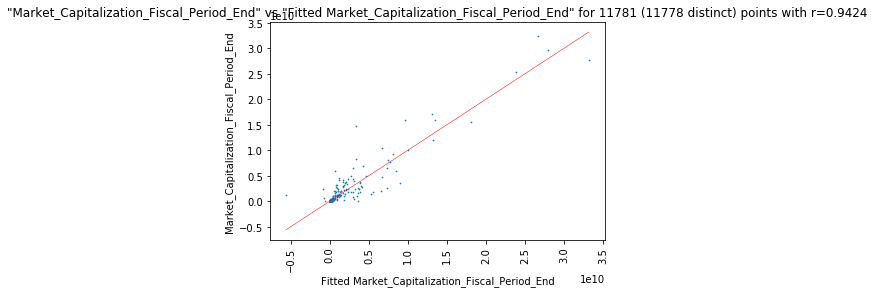

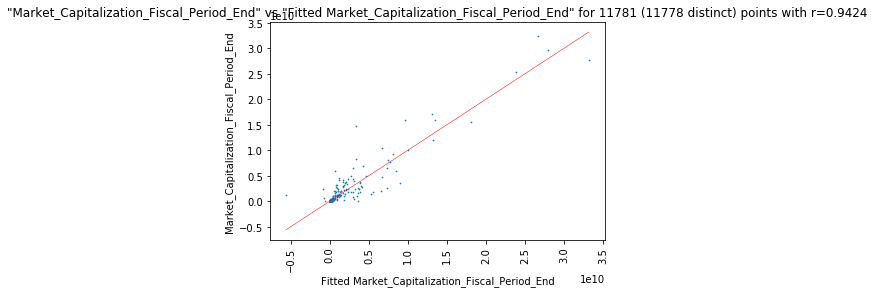

In [ ]:
selection = True

hout=smf.ols(bmodeleq, data=df2).fit()
    
#allvar = degrees of freedom used; mostly = number of Xs
allvar=int(round(sum(sm.stats.anova_lm(hout, typ=3)['df'][1:-1])))

print('F-statistic =',hout.fvalue,' using',allvar,'df(s):\n')
                
#display usual output tables:
#Anova table with 'Treatment' separated into components:    
hlm=sm.stats.anova_lm(hout, typ=3)
    
#OLS/Logit Regression Results:
hsum=hout.summary2()
print('\n',hsum)

#display extra statistics sorted by importance:
bval = hout.f_pvalue if minfpv == 'start' else minfpv
    
#number of bottom p-values to display with more precision; defaults to number of non-categorical variables:
last = int(round(sum(hlm['df'][:-1]==1.0)-1))
    
#p-values are the same as PR(>F)s from ANOVA typ=3
nxvar=len(hout.pvalues) #number of x variables plus intercepts
    
#any non-categorical variable
if last > 0:
    if min(hout.pvalues[nxvar-last:nxvar]) == 0.0:
        #some p-values for non-categorical variables are zero; sorting need to be done on F-stat and t-stat
        if nbest > last:
        #may include categorical variables:
            print('\nBest',nbest,"X-variables' F-stat (including categorical variables) ranked, using", allvar, 'df(s), via', crit ,'(='+str(abs(bval)) +'):')
        else:
            print('\n'+str(nbest),"X-variables' F-stat (including categorical variables) ranked, using", allvar, 'df(s):')
            print(hlm['F'][1:-1].sort_values(0, ascending=False)) # 0 is column number
        
        if nbest > 1:
            print('\n' +('Only ' if nbest > last else '')+str(last),"quantitative X-coefficients'", 't-stat', 'ranked, via', crit,'(='+str(abs(bval)) +'):')
            print(pd.concat([hout.tvalues[nxvar-last:nxvar],abs(hout.tvalues[nxvar-last:nxvar])],axis=1).sort_values(1, ascending=False)[0])
        else:
            #all non-categorical variables' p-values > 0
            if nbest > last:
                anovatable(uq,selection,nbest,crit,bval,hlm)

            if nbest > 1:
                #ignoring any categorical variables:
                print('\n'+('Only ' if (nbest > last) else '')+str(last),"quantitative X-coefficients'", 'P>|t|', 'ranked, via',
                              crit,'(='+str(abs(bval)) +'):')
            else:
                print('\n' +('Only ' if (nbest > last) else '')+str(last), "quantitative X-coefficients'", 'P>|t|', 'ranked:')
                print(hout.pvalues[nxvar-last:nxvar].sort_values(0, ascending=True)) # 0 is column number
    else:
        #all variables are categorical
        if nbest > 1:
            anovatable(uq,selection,nbest,crit,bval,hlm)
        
#plot y vs fit
yvsf(hout.fittedvalues, df2[yvar])
#print(dir(hout))
    
##Output Coefficient table:    
if modx > nbest and (hout.f_pvalue==0) and (crit=='PR(>F)'):
    print('\nAbove model may be too small (or too large if n is huge), since modeling may not work well when PR(>F) is 0.')
        
#display any smaller practicable model for management or client:
#if selection and mod5 != '' and mod5.count('+')+1 < nbest:
if mod5 != '' and mod5.count('+')+1 < nbest:
    hout=smf.ols(mod5, data=df2).fit()
    print('\nIf a warning message with peach background appeared,','the below model size should probably be reduced by at least 1.')

    if (crit == 'PR(>F)') or (crit == 'F'):
        bval=hout.f_pvalue
        if bval==0:
            #p-value for F-stat is 0, switch to F-stat itself;
            crit='F'
            bval=-hout.fvalue if uq != 2 else -hout.llr
        else:
            crit='PR(>F)'

    dc = True if min(hout.pvalues[1:]) > 0 else False #(smallest p) > 0 ?
    print("\nPractical '"+yvar+"' (median="+str(ymed)+") model's", mod5.count('+')+1,"X-coefficients'",
          'P>|t|' if dc else 't-stat', 'ranked, via', crit,'(='+str(abs(bval)) + '):')
    if dc:
        #print(hout.pvalues[1:].sort_values(0, ascending=True)) #without coefficients
        df = pd.concat([hout.params[1:],hout.pvalues[1:]],axis=1).sort_values(1, ascending=True)
        df.columns = ['Coefficient','P>|t|']
        print(df)
    else:
        df = pd.concat([hout.params[1:],hout.tvalues[1:],abs(hout.tvalues[1:])],axis=1 #hout.params return the coefficient of xvariables
                          ).sort_values(2,ascending=False).iloc[:,0:2] # sort via absolute t values but exclude the reporting of t values using iloc
        df.columns = ['Coefficient','t-stat']
        print(df)
            
#plot y vs fit
yvsf(hout.fittedvalues, df2[yvar], csv=False)

   
if 'fn' in vars():
    #remove data file written and read back in:
    if(os.path.exists(fn)):
        os.remove(fn)


#### Predictions


 Root Mean Square Error on Test Dataset:  253621357.23154533


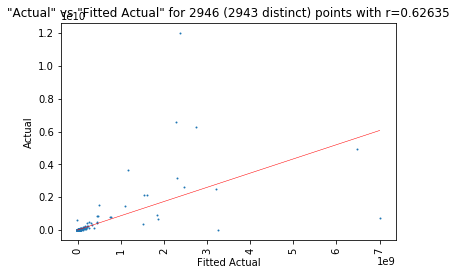

In [ ]:
df5 =df3.drop(['Market_Capitalization_Fiscal_Period_End'], axis=1)

ypred = hout.predict(df5)
pred_actual = pd.concat([ypred, df3['Market_Capitalization_Fiscal_Period_End']], ignore_index=True, axis=1)
#pred_actual.dtypes
#pred_actual.apply(pd.to_numeric)
#print(pred_actual)
columns = ['Predicted', 'Actual']
pred_actual = pd.DataFrame(pred_actual)
pred_actual.columns = columns
pred_actual['errors'] = pred_actual['Predicted']- pred_actual['Actual']
pred_actual['squared_errors'] = pred_actual['errors']**2

# compute rmse
rmse = statistics.mean(pred_actual['squared_errors'])
rmse = rmse**(1/2)
print('\n Root Mean Square Error on Test Dataset: ', rmse)

#plot actual vs predicted
yvsf(pred_actual['Predicted'], pred_actual['Actual'], csv=False)

### Part A - Multiple Linear Regression Model 2 (Backwise elimination of variables)


In [ ]:
data.head()

,Market_Capitalization_Fiscal_Period_End,Accounts_Receivables_Days,Accounts_Receivables_Days_5_Year_Average,Cash___Short_Term_Investments,Cash,Cash_Dividends_Paid_Total,Cash_Flow_Sales,Dividend_Yield_5_Year_Average_Low,EBIT_Total_Interest_Expense_Ratio,Equity_1_Year_Annual_Growth,...,Net_Income_After_Preferred_Dividends__Basic_EPS_,Net_Debt,Preferred_Stock___Total_Capital,Price_Earnings_Ratio_5_Year_Average_Average_High_Low,Price_Sales_Per_Share_Ratio,Return_On_Assets,Return_On_Assets_5_Year_Average,Return_On_Equity_Per_Share,Qualified,Unqualified
27,59708.0,357.338549,183.201462,17333.0,14962.0,579513.468872,17.81,4.210575,9.514,28.241998,...,1.539675e+06,1405.0,0.0,-1.217749e+12,0.71,7.088493,9.320146,1.373116,0,1
28,59708.0,155.000000,183.201462,10196.0,7681.0,3000.000000,4.01,4.210575,-3.396,-7.310000,...,-3.955000e+03,1601.0,0.0,-1.217749e+12,1.16,-3.570000,9.320146,-7.700000,0,1
29,39805.0,126.000000,183.201462,4890.0,4091.0,0.000000,5.83,4.210575,1.430,0.900000,...,1.200000e+01,9110.0,0.0,-1.217749e+12,0.71,0.530000,9.320146,0.020000,0,1
30,121729.0,111.000000,183.201462,11807.0,8800.0,0.000000,6.36,4.210575,2.525,29.850000,...,1.460000e+02,8774.0,0.0,-1.217749e+12,1.14,0.320000,9.320146,0.260000,0,1
31,86232.0,84.000000,183.201462,11010.0,11005.0,1991.543716,12.59,0.000000,18.409,15.570000,...,1.243094e+04,3106.0,0.0,2.292000e+01,0.49,10.910000,9.320146,17.940000,0,1


In [ ]:
X = data.drop('Market_Capitalization_Fiscal_Period_End', axis=1)
Y = data['Market_Capitalization_Fiscal_Period_End']

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 300)

import statsmodels.api as sm

#Backward Elimination - drop x varibles with p-value>0.0025
cols = list(X_train.columns)
pmax = 1
while (len(cols)>0):
    p= []
    X_1 = X_train[cols]
    X_1 = sm.add_constant(X_1)
    model = sm.OLS(Y_train.astype(float),X_1.astype(float)).fit()
    p = pd.Series(model.pvalues.values[1:],index = cols)      
    pmax = max(p)
    feature_with_p_max = p.idxmax()
    if(pmax>0.0025):
        cols.remove(feature_with_p_max)
    else:
        break
selected_features_BE = cols
print(selected_features_BE)
print(model.summary())

['Cash___Short_Term_Investments', 'Cash', 'Cash_Dividends_Paid_Total', 'Interest_Expense_On_Debt', 'Income_Taxes', 'Long_Term_Borrowings', 'Long_Term_Liabilities_Per_Share', 'Net_Sales_Or_Revenues', 'Net_Debt']
                                       OLS Regression Results                                      
Dep. Variable:     Market_Capitalization_Fiscal_Period_End   R-squared:                       0.888
Model:                                                 OLS   Adj. R-squared:                  0.888
Method:                                      Least Squares   F-statistic:                 1.037e+04
Date:                                     Mon, 18 Nov 2019   Prob (F-statistic):               0.00
Time:                                             18:35:34   Log-Likelihood:            -2.4388e+05
No. Observations:                                    11781   AIC:                         4.878e+05
Df Residuals:                                        11771   BIC:                        

In [ ]:
new_X_test = X_test[selected_features_BE]
new_X_train = X_train[selected_features_BE]

model = LinearRegression()
model.fit(new_X_train,Y_train)
print('Model score: '+str(model.score(new_X_test,Y_test)))

from sklearn.metrics import mean_squared_error
from math import sqrt
Y_predit = model.predict(new_X_test)
rmse = sqrt(mean_squared_error(Y_test, Y_predit))
print('RMSE: '+str(rmse))

Model score: 0.3802996411993568
RMSE: 254164690.1420851


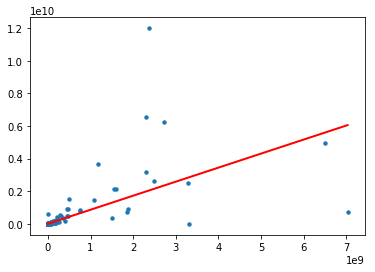

In [ ]:
s, i = np.polyfit(Y_predit, Y_test, 1) 
a, b = min(Y_predit), max(Y_predit)
pl.plot([a, b], i + [s * a, s * b], color='red', linewidth=2)
pl.scatter(Y_predit, Y_test, s=20, linewidths=0)
pl.show()

# Part B - Predicting Market Capitalization with Time Series

### Configure Google Colab Environment

In [1]:
!pip install pyramid
!pip install pyramid-arima
!pip uninstall statsmodels
!pip install numpy scipy patsy pandas
!pip install statsmodels

     |████████████████████████████████| 327kB 9.8MB/s 
     |████████████████████████████████| 174kB 46.5MB/s 
     |████████████████████████████████| 122kB 44.6MB/s 
     |████████████████████████████████| 604kB 9.3MB/s 
Uninstalling statsmodels-0.10.1:
  Would remove:
    /usr/local/LICENSE.txt
    /usr/local/lib/python3.6/dist-packages/statsmodels-0.10.1.dist-info/*
    /usr/local/lib/python3.6/dist-packages/statsmodels/*
    /usr/local/setup.cfg
Proceed (y/n)? y
  Successfully uninstalled statsmodels-0.10.1
     |████████████████████████████████| 8.1MB 9.8MB/s 


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.show()

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


## Data Preparation and Exploration: 'C344E1820','C392W1280','C392X3240'

In [ ]:
xl = pd.ExcelFile(u'drive/My Drive/Financial_Info_SG_Firms(Project).xlsx')

In [4]:
df_static = xl.parse("DATA_WORLDSCOPE_STATIC")
df_ts = xl.parse("DATA_WORLDSCOPE_TS",index_col='Year',parse_dates=True)
df_obs = xl.parse('Obs_Counts')
print(df_ts.shape)
print(df_static.shape)

(53277, 1386)
(1239, 161)


In [ ]:
relevant_columns = df_obs.iloc[:,3].dropna(axis = 0,how='all').tolist()+['Year']

In [ ]:
df_smry1 = df_ts[df_ts['Worldscope Permanent ID'].isin(['C344E1820','C392W1280','C392X3240'])].reset_index().groupby('Worldscope Permanent ID').agg(['min','max','count'])['Year']
# df_ts[df_ts['Worldscope Permanent ID'].isin(['C344E1820','C392W1280','C392X3240'])].groupby('Worldscope Permanent ID')['Market Capitalization Fiscal Period End']
df_ts['isnan'] = df_ts['Market Capitalization Fiscal Period End'].isna()
df_ts['yearisnan'] = df_ts['isnan']*df_ts.index.year
df_smry2 = df_ts[df_ts['Worldscope Permanent ID'].isin(['C344E1820','C392W1280','C392X3240'])].groupby('Worldscope Permanent ID')['Market Capitalization Fiscal Period End'].agg('count')
df_smry3 = df_ts[(df_ts['Worldscope Permanent ID'].isin(['C344E1820','C392W1280','C392X3240']))&(df_ts['yearisnan']!=0)].groupby('Worldscope Permanent ID')['yearisnan'].agg(['max','min'])
df_smry3.columns = ['max_missing','min_missing']
df_smry2.rename( 'Non-nan Count',inplace=True)
df_smry = df_smry1.merge(df_smry2,left_on='Worldscope Permanent ID',right_on='Worldscope Permanent ID')
df_smry = df_smry.merge(df_smry3,left_on='Worldscope Permanent ID',right_on='Worldscope Permanent ID')

In [7]:
df_smry

,min,max,count,Non-nan Count,max_missing,min_missing
Worldscope Permanent ID,,,,,,
C344E1820,1973-01-01,2015-01-01,43,36,1979,1973
C392W1280,1973-01-01,2015-01-01,43,36,1979,1973
C392X3240,1973-01-01,2015-01-01,43,36,1979,1973


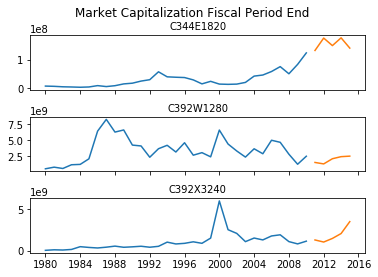

In [25]:
ts_agg = df_ts[df_ts['Worldscope Permanent ID'].isin(['C344E1820','C392W1280','C392X3240'])]
ts_agg = ts_agg[['Worldscope Permanent ID','Market Capitalization Fiscal Period End']]
ts_agg.dropna(inplace=True)
ts_agg['Market Capitalization Fiscal Period End'] = ts_agg['Market Capitalization Fiscal Period End'].astype(int)
ts_agg['Market Capitalization Fiscal Period End log'] = np.log(ts_agg['Market Capitalization Fiscal Period End'].astype(int))
# ts_agg.set_index('Year',inplace=True)
ts = pd.Series([])
train = pd.Series([])
valid = pd.Series([])
fig, axs = plt.subplots(3,sharex=True)
plt.subplots_adjust(hspace = 0.5 )
# fig.tight_layout()
fig.suptitle('Market Capitalization Fiscal Period End')
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  ts[i] = ts_agg[ts_agg['Worldscope Permanent ID'].isin([val])]['Market Capitalization Fiscal Period End']
  train[i] = ts[i][(ts[i].index.year>=1980)&(ts[i].index.year<=2010)]
  valid[i] = ts[i][ts[i].index.year>2010]
  axs[i].plot(train[i])
  axs[i].plot(valid[i])
  axs[i].set_title(val,fontsize=10)

## Time Series Preliminary Checks:
#### Seasonal Decomposition
#### Stationarity
#### Ljungbox 
#### ACF PACF Plot

### Seasonal Decompose

Multiplicative Decompose
C344E1820


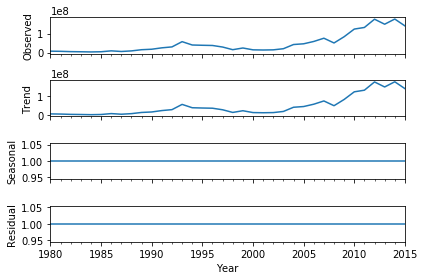

C392W1280


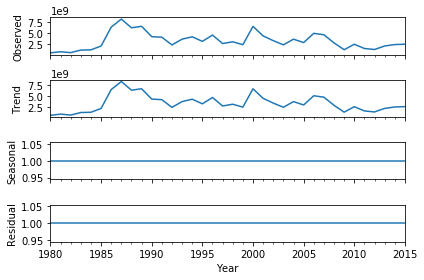

C392X3240


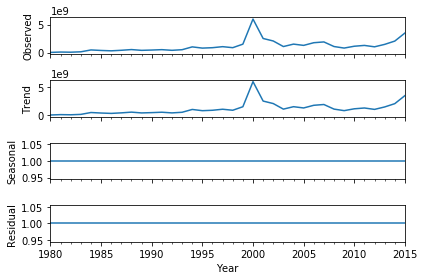

In [9]:
print('Multiplicative Decompose')
from statsmodels.tsa.seasonal import seasonal_decompose
# fig, axes = plt.subplots(ncols=3, nrows=4, sharex=True, figsize=(12,5))
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  print(val)
  result = seasonal_decompose(ts[i], model='multiplicative')
  result.plot()
  # plt.title(val, fontsize=8)
  plt.show()

Additive Decompose
C344E1820


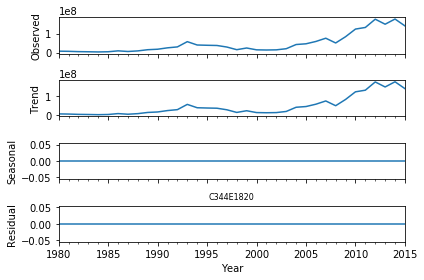

C392W1280


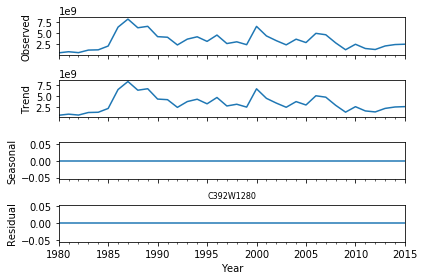

C392X3240


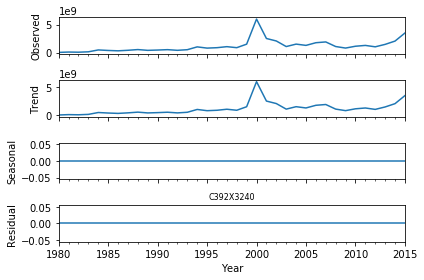

In [10]:
print('Additive Decompose')
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  print(val)
  result = seasonal_decompose(ts[i], model='additive')
  result.plot()
  plt.title(val, fontsize=8)
  plt.show()

### Stationary/Unit Root Test

ADF Test

In [11]:
from statsmodels.tsa.stattools import adfuller as ADF
from statsmodels.tsa.statespace.tools import diff

adf_list = []
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  adf_list.append([val]+list(ADF(train[i],3)[:4]))
print('Company,   t-stats,  p-value')
adf_list

Company,   t-stats,  p-value


[['C344E1820', 0.9252603411069629, 0.993411282649817, 0, 30],
 ['C392W1280', -2.8337821390443314, 0.05360790442939378, 0, 30],
 ['C392X3240', -3.094433042208759, 0.026967920735077144, 0, 30]]

In [12]:
print('diff = 1')
adf_list_diff = []
d_train=pd.Series([])
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  d_train[i] = diff(train[i],k_diff=1).dropna()
  adf_list_diff.append([val]+list(ADF(d_train[i].dropna(),3)[:4]))
print('Company,   t-stats,  p-value')
adf_list_diff

diff = 1
Company,   t-stats,  p-value


[['C344E1820', -4.619786816958091, 0.0001187462922603693, 0, 29],
 ['C392W1280', -5.959355885640734, 2.0566151998703689e-07, 0, 29],
 ['C392X3240', -7.275849479007575, 1.5452399853055276e-10, 0, 29]]

### Ljung Box Text

White Noise Test

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox
ljungbox_list = []
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  ljungbox_list.append([val]+list(acorr_ljungbox(train[i])))
# print(acorr_ljungbox(train1,lags=3))
# print(acorr_ljungbox(d_train1,lags=3))
ljungbox_list

[['C344E1820',
  array([15.2206238 , 23.6810145 , 31.0959157 , 33.2588859 , 33.57820243,
         33.59023518, 34.39110297, 35.56746954, 36.76031065, 37.18551877,
         37.20992129, 37.2129862 , 37.64725759]),
  array([9.56530693e-05, 7.20664350e-06, 8.11422327e-07, 1.05721491e-06,
         2.88859272e-06, 8.07075445e-06, 1.45512348e-05, 2.10680198e-05,
         2.90402883e-05, 5.25599078e-05, 1.06260668e-04, 2.06315048e-04,
         3.27755574e-04])],
 ['C392W1280',
  array([11.80535475, 14.51419083, 14.6031479 , 15.35335783, 18.39844607,
         20.98343606, 22.58522995, 24.90924132, 26.54354062, 26.59757789,
         26.70826397, 26.87374844, 27.46309109]),
  array([0.00059061, 0.00070515, 0.0021892 , 0.00402174, 0.00248634,
         0.00184723, 0.00201237, 0.00161057, 0.00166366, 0.0030144 ,
         0.00508487, 0.00805709, 0.01074398])],
 ['C392X3240',
  array([ 8.67479618, 12.36477445, 13.78713901, 15.26021865, 16.44587062,
         18.52098965, 19.2715719 , 19.29268473, 19.5

In [14]:
print('when order difference d = 1')
from statsmodels.stats.diagnostic import acorr_ljungbox
ljungbox_list = []
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  ljungbox_list.append([val]+list(acorr_ljungbox(d_train[i])))
# print(acorr_ljungbox(train1,lags=3))
# print(acorr_ljungbox(d_train1,lags=3))
ljungbox_list

when order difference d = 1


[['C344E1820',
  array([0.01021999, 0.15598851, 2.06685041, 2.08826281, 2.08887407,
         2.46631971, 2.62439028, 2.66077261, 5.54717271, 5.66778643,
         5.95581674, 7.82942317, 7.84526467]),
  array([0.91947585, 0.92496974, 0.55864821, 0.719529  , 0.83671601,
         0.87221782, 0.91744281, 0.95381203, 0.78424313, 0.84235957,
         0.87629595, 0.79831428, 0.85353276])],
 ['C392W1280',
  array([ 0.66847344,  0.69884475,  3.47526404,  3.6316366 ,  5.45234423,
          6.03324455,  7.35984532,  8.4658824 ,  9.21129245,  9.29284728,
          9.38807543,  9.9861042 , 11.45845145]),
  array([0.41358434, 0.70509525, 0.32398449, 0.45814691, 0.36319981,
         0.41947633, 0.39239825, 0.3893326 , 0.41800324, 0.50455517,
         0.58611829, 0.61717978, 0.57246968])],
 ['C392X3240',
  array([3.49415788, 3.61605255, 4.24670029, 4.28607842, 4.53448911,
         5.38412798, 5.57359913, 6.11235315, 6.38804992, 6.4856094 ,
         6.51324533, 6.55068797, 6.55936733]),
  array([0.0615

### ACF and PACF

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

original time series


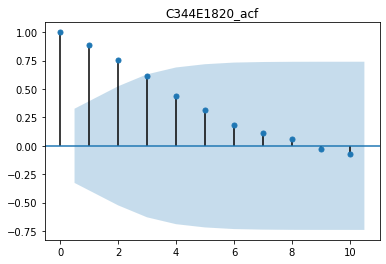

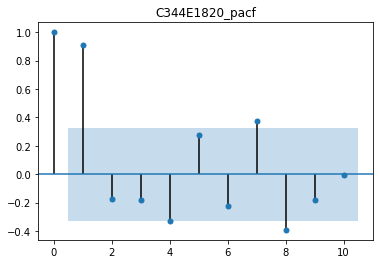

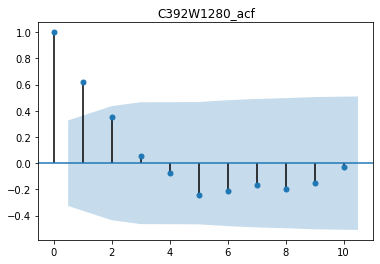

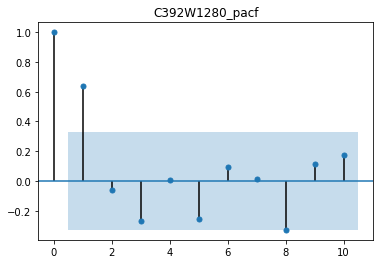

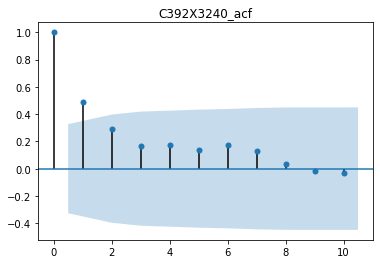

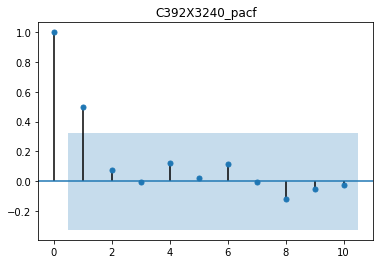

In [16]:
print('original time series')
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  plot_acf(ts[i], lags=10,title=val+'_acf');
  plot_pacf(ts[i],lags=10,title=val+'_pacf');

order difference d = 1


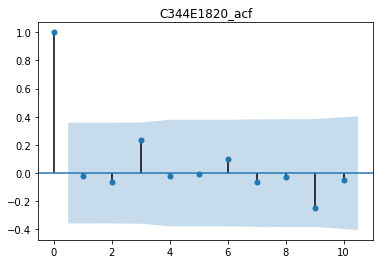

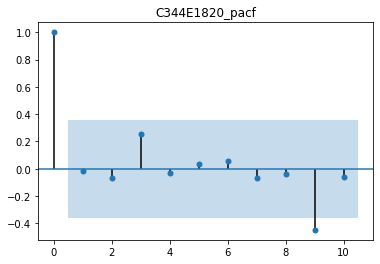

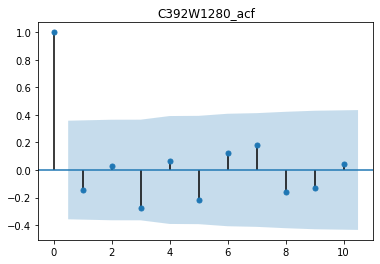

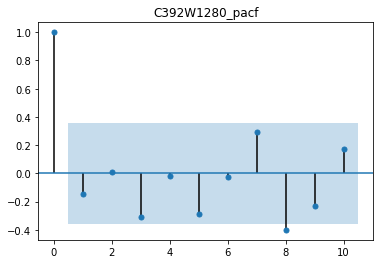

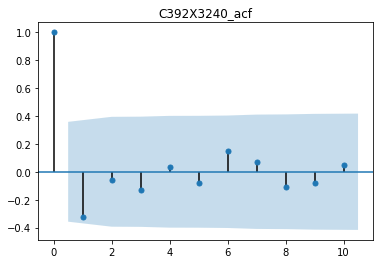

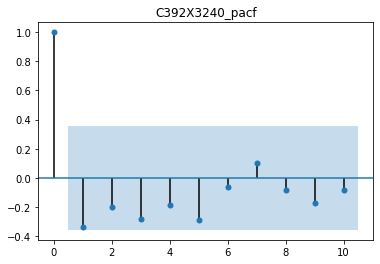

In [17]:
print('order difference d = 1')
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  plot_acf(d_train[i],lags=10,title=val+'_acf');
  plot_pacf(d_train[i],lags=10,title=val+'_pacf');

## Model Building
### AutoArima (stepwise model fitting and forecast)
### Exponential Smoothing (Simple, Holt-Winters grid searching and forecast)

### AutoArima

In [ ]:
def ts_performance(valid,forecast,is_print=True):
  rms = sqrt(mean_squared_error(valid,forecast))
  avg = valid.mean()
  prctg_rms = rms*100./valid.mean()
  mape = np.mean(np.abs((valid - forecast) / valid)) * 100
  if is_print:
    print('rmse:'+str(rms))
    print('average:'+str(avg))
    print('% error:'+str(prctg_rms))
    print('MAPE:'+str(mape))
  return rms,avg,prctg_rms,mape

model for C344E1820
Fit ARIMA: order=(5, 1, 5); AIC=nan, BIC=nan, Fit time=nan seconds
Fit ARIMA: order=(0, 1, 0); AIC=1074.687, BIC=1077.489, Fit time=0.002 seconds
Fit ARIMA: order=(1, 1, 0); AIC=1076.675, BIC=1080.879, Fit time=0.013 seconds
Fit ARIMA: order=(0, 1, 1); AIC=1076.673, BIC=1080.877, Fit time=0.036 seconds
Fit ARIMA: order=(1, 1, 1); AIC=nan, BIC=nan, Fit time=nan seconds
Total fit time: 0.080 seconds


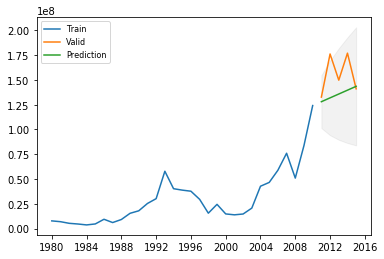

                             ARIMA Model Results                              
Dep. Variable:                    D.y   No. Observations:                   30
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -535.343
Method:                           css   S.D. of innovations       13603586.540
Date:                Tue, 19 Nov 2019   AIC                           1074.687
Time:                        02:30:06   BIC                           1077.489
Sample:                             1   HQIC                          1075.583
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.879e+06   2.48e+06      1.562      0.129   -9.89e+05    8.75e+06
rmse:26758504.846064
average:155299605.6
% error:17.23024649205162
MAPE:12.176810478589488
model for C392W1280
Fit ARIMA: order=(5,

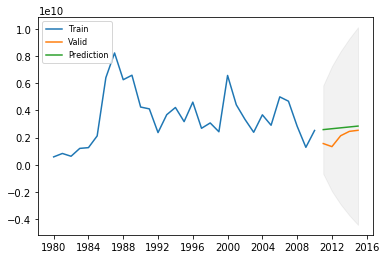

                             ARIMA Model Results                              
Dep. Variable:                    D.y   No. Observations:                   30
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -679.448
Method:                           css   S.D. of innovations     1658743484.386
Date:                Tue, 19 Nov 2019   AIC                           1362.896
Time:                        02:30:08   BIC                           1365.698
Sample:                             1   HQIC                          1363.792
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.473e+07   3.03e+08      0.214      0.832   -5.29e+08    6.58e+08
rmse:815674555.033387
average:2010206993.0
% error:40.57664498600155
MAPE:43.257561061873524
model for C392X3240
Fit ARIMA: order=(

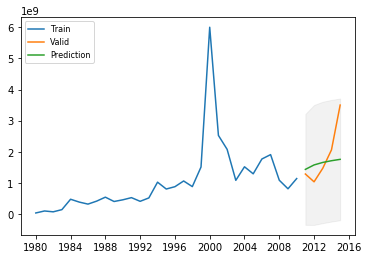

                             ARIMA Model Results                              
Dep. Variable:                    D.y   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -662.699
Method:                       css-mle   S.D. of innovations      908970163.152
Date:                Tue, 19 Nov 2019   AIC                           1333.397
Time:                        02:30:10   BIC                           1339.002
Sample:                             1   HQIC                          1335.190
                                                                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.685e+07   3.42e+07      1.076      0.291   -3.03e+07    1.04e+08
ar.L1.D.y      0.4116      0.199      2.063      0.049       0.021       0.803
ma.L1.D.y     -0.9996      0.344     -2.908      0.0

In [26]:
from pyramid.arima import auto_arima
from math import sqrt
from sklearn.metrics import mean_squared_error
model = []
forecast=[]
for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
  print("==========================================================")
  print('model for '+val)
  if val == 'C392X3240':
    model = auto_arima(train[i],trace=True, error_action='ignore', suppress_warnings=True,seasonal=False,step_wise=True,start_p=5, max_p=10,
                          start_q=5, max_q=10,max_d = 1,scoring='mse',information_criterion='aic')
  else:
    model = auto_arima(train[i], trace=True, error_action='ignore', suppress_warnings=True,seasonal=False,step_wise=True,start_p=5, max_p=10,
                          start_q=5, max_q=10,d=1,scoring='mse',information_criterion='aic')
  model.fit(train[i])
  # print('model aic: '+str(model.aic()))
  forecast,conf_int = model.predict(n_periods=len(valid[i]),return_conf_int=True,alpha=0.05)
  conf_int = pd.DataFrame(conf_int,columns=['lower','higher'])
  forecast = pd.DataFrame(forecast,index = valid[i].index,columns=['Prediction'])

  plt.plot(train[i], label='Train')
  plt.plot(valid[i], label='Valid')
  plt.plot(forecast, label='Prediction')
  plt.fill_between(forecast.index, conf_int['lower'],conf_int['higher'], color='k', alpha=.05)
  plt.legend(loc='upper left', fontsize=8)
  plt.show()

  print(model.summary())
  #calculate rmse
  ts_performance(valid[i],forecast['Prediction'])
  # rms = sqrt(mean_squared_error(valid[i],forecast))
  # print('rmse:'+str(rms))
  # print('average:'+str(valid[i].mean()))
  # print('% error:'+str(rms*100./valid[i].mean()))
  # print('MAPE:'+str(np.mean(np.abs((valid[i] - forecast['Prediction']) / valid[i])) * 100))

### Exponential Smoothing

In [20]:
from math import sqrt
from multiprocessing import cpu_count
from joblib import Parallel
from joblib import delayed
from warnings import catch_warnings
from warnings import filterwarnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
from numpy import array

def exp_smoothing_forecast(history, config):
	t,d,s,p,b,r = config
  # t is_trended
  # d is_damped
  # s is_seasonal
  # p seasonal period
  # b boxcox 
  # r remove bias
	# define model
	history = array(history)
	model = ExponentialSmoothing(history, trend=t, damped=d, seasonal=s, seasonal_periods=p)
	# fit model
	model_fit = model.fit(optimized=True, use_boxcox=b, remove_bias=r)
	# make one step forecast
	yhat = model_fit.predict(len(history), len(history))
	return yhat[0]

 
# root mean squared error or rmse
def measure_rmse(actual, predicted):
	return sqrt(mean_squared_error(actual, predicted))
 
# split a univariate dataset into train/test sets
def train_test_split(data, n_test):
	return data[data.index.year<=n_test].values.tolist(), data[data.index.year>n_test].values.tolist()
 
# walk-forward validation for univariate data
def walk_forward_validation(data, n_test, cfg):
	predictions = list()
	# split dataset
	train, test = train_test_split(data, n_test)
	# seed history with training dataset
	history = [x for x in train]
	# step over each time-step in the test set
	for i in range(len(test)):
		# fit model and make forecast for history
		yhat = exp_smoothing_forecast(history, cfg)
		# store forecast in list of predictions
		predictions.append(yhat)
		# add actual observation to history for the next loop
		history.append(test[i])
	# estimate prediction error
	error = measure_rmse(test, predictions)
	return error
 
# score a model, return None on failure
def score_model(data, n_test, cfg, debug=False):
	result = None
	# convert config to a key
	key = str(cfg)
	# show all warnings and fail on exception if debugging
	if debug:
		result = walk_forward_validation(data, n_test, cfg)
	else:
		# one failure during model validation suggests an unstable config
		try:
			# never show warnings when grid searching, too noisy
			with catch_warnings():
				filterwarnings("ignore")
				result = walk_forward_validation(data, n_test, cfg)
		except:
			error = None
	# check for an interesting result
	if result is not None:
		print(' > Model[%s] %.3f' % (key, result))
  
	return (key, result)
 
# grid search configs
def grid_search(data, cfg_list, n_test, parallel=True):
	scores = None
	if parallel:
		# execute configs in parallel
		executor = Parallel(n_jobs=cpu_count(), backend='multiprocessing')
		tasks = (delayed(score_model)(data, n_test, cfg) for cfg in cfg_list)
		scores = executor(tasks)
	else:
		scores = [score_model(data, n_test, cfg) for cfg in cfg_list]
	# remove empty results
	scores = [r for r in scores if r[1] != None]
	# sort configs by error, asc
	scores.sort(key=lambda tup: tup[1])
	return scores
 
# create a set of exponential smoothing configs to try
def exp_smoothing_configs(seasonal=[None]):
	models = list()
	# define config lists
	t_params = ['add', 'mul', None]
	d_params = [True, False,None]
	s_params = ['add', 'mul', None]
	p_params = seasonal
	b_params = [True, False,None]
	r_params = [True, False,None]
	# create config instances
	for t in t_params:
		for d in d_params:
			for s in s_params:
				for p in p_params:
					for b in b_params:
						for r in r_params:
							cfg = [t,d,s,p,b,r]
							models.append(cfg)
	return models
 
if __name__ == '__main__':
	# define dataset
  for i,val in enumerate(['C344E1820','C392W1280','C392X3240']):
    print("=======================================================")
    print('running for Company: '+val)
    data = ts[i]
    # data split
    n_test = 2010
    # model configs
    cfg_list = exp_smoothing_configs()
    # grid search
    scores = grid_search(data, cfg_list, n_test)
    print('done')
    # list top 3 configs
    for cfg, error in scores[:3]:
      print('top 3 model')
      print(cfg, error)

running for Company: C344E1820
 > Model[['add', True, None, None, True, None]] 66061990.516
 > Model[['add', True, None, None, True, True]] 58092930.909
 > Model[['add', True, None, None, False, True]] 33011008.680
 > Model[['add', True, None, None, True, False]] 66061990.516
 > Model[['add', True, None, None, False, False]] 32000056.216
 > Model[['add', True, None, None, None, True]] 33011008.680
 > Model[['add', True, None, None, False, None]] 32000056.216
 > Model[['add', True, None, None, None, False]] 32000056.216
 > Model[['add', False, None, None, True, True]] 34579283.146
 > Model[['add', False, None, None, True, False]] 34011927.287
 > Model[['add', False, None, None, True, None]] 34011927.287
 > Model[['add', False, None, None, False, True]] 34248561.351
 > Model[['add', False, None, None, False, False]] 33215279.191
 > Model[['add', False, None, None, False, None]] 33215279.191
 > Model[['add', True, None, None, None, None]] 32000056.216
 > Model[['add', False, None, None, N

Permanent ID: C344E1820


/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/holtwinters.py:712: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  ConvergenceWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/holtwinters.py:712: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  ConvergenceWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/holtwinters.py:712: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  ConvergenceWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/holtwinters.py:712: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  ConvergenceWarning)
/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/holtwinters.py:712: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  ConvergenceWarning)


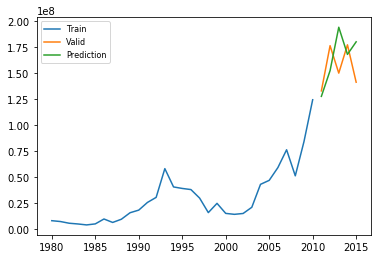

rmse:28810876.53452178
average:155299605.6
% error:18.55180277065802
MAPE:15.975751841562316


(28810876.53452178, 155299605.6, 18.55180277065802, 15.975751841562316)

In [21]:
print('Permanent ID: C344E1820')
cfg = ['mul', True, None, None, True, False]
predictions = list()
# split dataset
train, test = train_test_split(ts[0], n_test)
# seed history with training dataset
history = [x for x in train]
# step over each time-step in the test set
for i in range(len(test)):
  # fit model and make forecast for history
  yhat = exp_smoothing_forecast(history, cfg)
  # store forecast in list of predictions
  predictions.append(yhat)
  # add actual observation to history for the next loop
  history.append(test[i])

train = pd.DataFrame(train)
train.index = range(1980,2011)
test = pd.DataFrame(test)
test.index = range(2011,2016)
predictions = pd.DataFrame(predictions)
predictions.index = range(2011,2016)
#plot the predictions for validation set
plt.plot(train, label='Train')
plt.plot(test, label='Valid')
plt.plot(predictions, label='Prediction')
plt.legend(loc='upper left', fontsize=8)
plt.show()
ts_performance(test[0],predictions[0])

Permanent ID: C392W1280


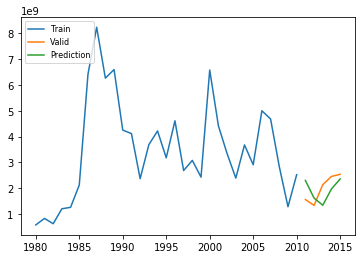

rmse:552513114.4629036
average:2010206993.0
% error:27.485384161276947
MAPE:26.430733647194476


(552513114.4629036, 2010206993.0, 27.485384161276947, 26.430733647194476)

In [22]:
print('Permanent ID: C392W1280')
cfg = ['mul', False, None, None, True, False]
predictions = list()
# split dataset
train, test = train_test_split(ts[1], n_test)
# seed history with training dataset
history = [x for x in train]
# step over each time-step in the test set
for i in range(len(test)):
  # fit model and make forecast for history
  yhat = exp_smoothing_forecast(history, cfg)
  # store forecast in list of predictions
  predictions.append(yhat)
  # add actual observation to history for the next loop
  history.append(test[i])

train = pd.DataFrame(train)
train.index = range(1980,2011)
test = pd.DataFrame(test)
test.index = range(2011,2016)
predictions = pd.DataFrame(predictions)
predictions.index = range(2011,2016)
#plot the predictions for validation set
plt.plot(train, label='Train')
plt.plot(test, label='Valid')
plt.plot(predictions, label='Prediction')
plt.legend(loc='upper left', fontsize=8)
plt.show()
ts_performance(test[0],predictions[0])

Permanent ID: C392X3240


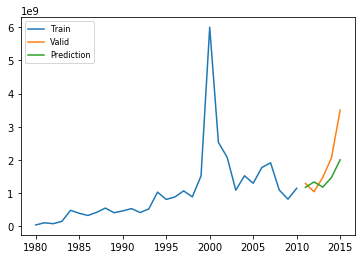

rmse:748196234.7331724
average:1870739572.4
% error:39.9946762110399
MAPE:25.945568254990782


(748196234.7331724, 1870739572.4, 39.9946762110399, 25.945568254990782)

In [23]:
print('Permanent ID: C392X3240')
cfg = ['mul', False, None, None, True, True]
predictions = list()
# split dataset
train, test = train_test_split(ts[2], n_test)
# seed history with training dataset
history = [x for x in train]
# step over each time-step in the test set
for i in range(len(test)):
  # fit model and make forecast for history
  yhat = exp_smoothing_forecast(history, cfg)
  # store forecast in list of predictions
  predictions.append(yhat)
  # add actual observation to history for the next loop
  history.append(test[i])

train = pd.DataFrame(train)
train.index = range(1980,2011)
test = pd.DataFrame(test)
test.index = range(2011,2016)
predictions = pd.DataFrame(predictions)
predictions.index = range(2011,2016)
#plot the predictions for validation set
plt.plot(train, label='Train')
plt.plot(test, label='Valid')
plt.plot(predictions, label='Prediction')
plt.legend(loc='upper left', fontsize=8)
plt.show()
ts_performance(test[0],predictions[0])